# 05. Commercial Signal — 서울 전체 상권 변화 신호 체계 구축

## 이 노트북의 목적

`04_feature_engineering.ipynb`는 서울 전체 상권에 대해 `기준_년분기_코드 x 상권_코드` grain으로 71개의 해석 가능한 feature를 구축했다.
이번 `05_commercial_signal.ipynb`의 목적은 이 feature들을 다시 시각화하는 것이 아니라, 다음 질문에 답할 수 있는 **상권 변화 신호 체계**를 만드는 것이다.

1. 이 상권은 서울 동일 분기 대비 상대적 증가 방향인가, 상대적 감소 방향인가? (Momentum / Direction)
2. 기존 구조가 크게 변하고 있는가? (Structural Change)
3. 매출·유동인구·점포의 움직임이 서로 어긋나고 있는가? (Decoupling)
4. 최근 변동성이 비정상적으로 큰가? (Instability)
5. 같은 시점의 서울 전체 상권과 비교했을 때 얼마나 특이한가? (Isolation Forest)
6. 현재 어떤 변화 유형의 상권과 유사한가? (Clustering)
7. 황학동 4개 상권에서는 어떤 신호가 나타나는가?

**중요**: 이 분석은 쇠퇴를 예측하는 supervised prediction 모델이 아니다. 정답 label이 없기 때문에 규칙 기반 해석 가능한 signal, 비지도 이상탐지(Isolation Forest), 비지도 군집분석(KMeans)을 이용해 상권의 **현재 관측된 변화 상태**를 정량화한다. 따라서 결과를 "미래에 쇠퇴할 확률"처럼 표현하지 않고, "현재 관측된 데이터에서 서울 다른 상권과 비교하여 강한 감소·구조변화·이상 신호가 나타난다"처럼 표현한다.

## 기본 원칙

1. **서울 전체를 기준집단으로 사용한다.** 황학동만으로 모델을 만들지 않는다. 서울 전체 상권에 동일한 signal을 계산하고, 그 분포/AI 기준 위에 황학동 4개 상권의 위치를 확인한다. 황학동 여부 자체는 어떤 model의 feature로도 사용하지 않는다.
2. **동일 분기 비교 원칙을 유지한다.** 서울 상권 전체가 시간에 따라 경기·소비환경의 영향을 함께 받을 수 있으므로, 가능한 신호는 `groupby("기준_년분기_코드")` 기준으로 **같은 분기 안에서** 상대적으로 비교한다. 서로 다른 분기를 직접 rank하지 않는다.
3. **초기 YoY 결측 구조를 유지한다.** `04`에서 YoY 계열 feature는 2021년에 구조적으로 `NaN`이었다. 이번 노트북에서 실제 결측 구조를 다시 확인한 뒤 signal 분석 기간을 결정한다(섹션 5). 2021년 데이터를 임의로 채우지 않는다.
4. **결측치를 0으로 대체하지 않는다.** `has_sales`/`has_population`/`complete_case`의 의미를 유지하고, signal 계산에 필요한 feature가 없는 행은 `signal_eligible=False`로 명시적으로 구분한다. AI score는 `NaN`으로 유지하며 임의 평균대체·0대체를 하지 않는다.
5. **71개 feature를 모두 AI에 넣지 않는다.** raw YoY / log growth / percentile처럼 같은 개념을 중복 표현하는 feature를 동시에 넣지 않고, 개념별 대표 feature만 선택한다. `total_sales`/`store_count`/`floating_population` 같은 절대규모 feature는 맥락(context) 해석용으로 남기고, 변화 탐지 모델의 핵심 입력에서는 제외한다.
6. **도메인 정보(domain-informed) feature는 AI 모델 입력에서 제외한다.** `furniture_sales_share`/`korean_food_sales_share`/`ecommerce_sales_share`는 `03_eda.ipynb`에서 황학동을 분석한 뒤 사전에 선정한 feature이므로, 이 정보가 서울 전체 AI 모델의 핵심 기준이 되지 않도록 Isolation Forest/Clustering 입력에서 제외하고, 결과가 나온 뒤 황학동을 해석할 때만 사용한다.
7. **"증가/감소"는 항상 서울 동일 분기 대비 상대적 표현이다.** `direction_score`의 구성요소는 모두 동일 분기 서울 내 percentile이므로, `direction_score > 0`이라고 해서 실제 YoY가 반드시 양수인 것은 아니다. 서울 전체가 감소한 분기에는 실제 YoY가 음수여도 다른 상권보다 덜 감소했다는 이유로 높은 percentile을 받을 수 있다. 따라서 이 노트북 전체에서 "성장"/"감소"라는 절대적 표현 대신 "서울 대비 상대적 증가/감소 방향"이라는 표현을 사용한다.

## 방법론 구조

```
04 features ── direction / structural change / decoupling / instability (해석 가능한 signal)
                              │
                ┌─────────────┴─────────────┐
                ↓                           ↓
        Isolation Forest              Clustering
        (이상 변화 탐지)                (변화 유형 탐색)
                └─────────────┬─────────────┘
                              ↓
                      황학동 4개 상권 진단
```

AI는 기존 분석을 대체하지 않는다. `04`에서 만든 정량 지표를 서울 전체 상권과 비교하고 패턴화하는 역할을 한다. 이 중 **황학동 4개 상권의 최종 진단·정책 추천(`07_strategy_recommendation.ipynb`)에 직접 연결되는 것은 Isolation Forest(`anomaly_percentile`)와 `06`의 Nearest Neighbor(Peer Benchmark)이며, Clustering(KMeans)은 서울 상권 전체의 변화 유형을 탐색하는 보조 분석으로 `latest_commercial_typology.csv`에만 저장되고 `07`의 진단·전략 로직에는 사용하지 않는다.**

## 이번 노트북에서 하지 않는 것

미래 매출 예측, 상권 쇠퇴 supervised classification, 임의의 정답 label 생성 후 정확도 평가, XGBoost/LightGBM 예측, SHAP 기반 예측 설명, LLM API 호출, 자동 정책 추천, 상가 입지 추천, 유사 상권 Top-N 추천 시스템, 대시보드 제작, 황학동 활성화 정책 최종 제안은 이번 단계에서 다루지 않는다.

## 해석상 주의

- "쇠퇴 확률 90%", "AI가 쇠퇴 상권으로 판정했다" 같은 표현을 쓰지 않는다.
- 대신 "서울 동일 분기 상권과 비교했을 때 상대적 감소 방향 신호가 강하다", "Isolation Forest 기준으로 변화 패턴의 이상성이 높게 나타난다"처럼 표현한다.
- 상관·동시발생과 인과관계를 구분한다.

## 1. 라이브러리 / 경로 / random seed

`02_preprocessing.ipynb`~`04_feature_engineering.ipynb`와 동일하게 `notebooks/` 폴더 기준 상대경로(`../data/processed`)로 접근한다. 이 노트북에서 새로 추가되는 라이브러리는 `scikit-learn`(RobustScaler, IsolationForest, KMeans, PCA, 평가지표)뿐이다.

In [1]:
%matplotlib inline
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

PROCESSED_DIR = Path("../data/processed")
FEATURES_PATH = PROCESSED_DIR / "commercial_features.csv"
DICTIONARY_PATH = PROCESSED_DIR / "feature_dictionary.csv"

SIGNALS_OUT_PATH = PROCESSED_DIR / "commercial_signals.csv"
TYPOLOGY_OUT_PATH = PROCESSED_DIR / "latest_commercial_typology.csv"
SIGNAL_DICTIONARY_OUT_PATH = PROCESSED_DIR / "signal_dictionary.csv"
ANOMALY_DRIVERS_OUT_PATH = PROCESSED_DIR / "hwanghak_anomaly_drivers.csv"

for name, p in [("FEATURES_PATH", FEATURES_PATH), ("DICTIONARY_PATH", DICTIONARY_PATH)]:
    print(f"{name:16s} {p} -> exists: {p.exists()}")
print("RANDOM_STATE =", RANDOM_STATE)

FEATURES_PATH    ..\data\processed\commercial_features.csv -> exists: True
DICTIONARY_PATH  ..\data\processed\feature_dictionary.csv -> exists: True
RANDOM_STATE = 42


In [2]:
# 03/04와 동일한 스타일의 그래프 설정
sns.set_theme(style="whitegrid")

_KOREAN_FONT_CANDIDATES = [
    "Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
    "Noto Sans CJK KR", "Noto Sans KR", "Gulim",
]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
_font_name = next((c for c in _KOREAN_FONT_CANDIDATES if c in _available_fonts), None)

if _font_name:
    plt.rcParams["font.family"] = _font_name
    print(f"한글 폰트 설정: {_font_name}")
else:
    print("경고: 사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글 라벨이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

import logging
logging.getLogger("matplotlib").setLevel(logging.ERROR)
plt.rcParams["figure.dpi"] = 100

SEOUL_COLOR = "#9E9E9E"
HWANGHAK_COLOR = "#C0392B"
AREA_PALETTE = sns.color_palette("Set2", 4)

한글 폰트 설정: Malgun Gothic


## 2. `commercial_features` 및 `feature_dictionary` 로드

`04_feature_engineering.ipynb`가 저장한 Feature Table과 Feature Dictionary를 원본 그대로 불러온다. 이 노트북은 `commercial_features.csv`를 절대 덮어쓰지 않는다.

In [3]:
features = pd.read_csv(FEATURES_PATH, encoding="utf-8-sig")
feature_dictionary = pd.read_csv(DICTIONARY_PATH, encoding="utf-8-sig")

print("features shape:", features.shape)
print("feature_dictionary shape:", feature_dictionary.shape)
print("분기 범위:", features["기준_년분기_코드"].min(), "~", features["기준_년분기_코드"].max(),
      f"({features['기준_년분기_코드'].nunique()}개 분기)")
print("상권 수:", features["상권_코드"].nunique())
features.head(3)

features shape: (33000, 81)
feature_dictionary shape: (75, 5)
분기 범위: 20211 ~ 20254 (20개 분기)
상권 수: 1650


,기준_년분기_코드,분기_라벨,상권_코드,상권_코드_명,상권_구분_코드,상권_구분_코드_명,has_sales,has_stores,has_population,complete_case,total_sales,total_transactions,avg_transaction_value,store_count,floating_population,opening_store_count,closing_store_count,franchise_store_count,net_store_change,franchise_share,opening_intensity,closing_intensity,weekday_sales_share,weekend_sales_share,late_night_sales_share,morning_sales_share,daytime_sales_share,evening_night_sales_share,sales_age_10_share,sales_age_20_share,sales_age_30_share,sales_age_40_share,sales_age_50_share,sales_age_60plus_share,sales_age_2030_share,pop_age_10_share,pop_age_20_share,pop_age_30_share,pop_age_40_share,pop_age_50_share,pop_age_60plus_share,pop_age_2030_share,age_2030_gap,age_60plus_gap,furniture_sales_share,korean_food_sales_share,ecommerce_sales_share,top1_industry_share,top3_industry_share,industry_hhi,active_industry_count,sales_qoq,sales_yoy,transactions_qoq,transactions_yoy,stores_qoq,stores_yoy,population_qoq,population_yoy,sales_yoy_log_growth,population_yoy_log_growth,stores_yoy_log_growth,sales_4q_mean,sales_4q_std,sales_4q_cv,population_4q_mean,store_4q_mean,sales_population_yoy_gap,sales_store_yoy_gap,sales_population_log_growth_gap,sales_store_log_growth_gap,sales_population_percentile_gap,sales_store_percentile_gap,sales_percentile,store_percentile,population_percentile,sales_yoy_percentile,population_yoy_percentile,stores_yoy_percentile,weekend_share_percentile,evening_share_percentile
0,20211,2021Q1,3001491,이태원 관광특구,U,관광특구,True,True,True,True,6.339763e+10,2228118.0,28453.442401,1546,1747889.0,29,46,87,-17,0.056274,0.018758,0.029754,0.607999,0.392001,0.016103,0.029946,0.471457,0.482494,0.007816,0.327946,0.313562,0.164571,0.119493,0.066611,0.641508,0.058405,0.226318,0.236111,0.165926,0.134929,0.178311,0.462429,0.179080,-0.111700,0.000750,0.101181,0.000046,0.152167,0.436119,0.095282,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.635709,-0.515806,96.696315,97.212121,88.060606,NaN,NaN,NaN,95.743329,70.203304
1,20212,2021Q2,3001491,이태원 관광특구,U,관광특구,True,True,True,True,8.158495e+10,2878581.0,28342.071618,1551,1885158.0,54,50,86,4,0.055448,0.034816,0.032237,0.620169,0.379831,0.014581,0.028102,0.451453,0.505865,0.009183,0.340771,0.305606,0.155276,0.123843,0.065321,0.646377,0.059294,0.237663,0.234941,0.167274,0.131260,0.169568,0.472604,0.173773,-0.104247,0.001332,0.104299,0.000042,0.171726,0.446431,0.100223,37.0,28.687701,NaN,29.193382,NaN,0.323415,NaN,7.853416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.899767,0.051282,97.202797,97.151515,90.303030,NaN,NaN,NaN,94.342022,72.981564
2,20213,2021Q3,3001491,이태원 관광특구,U,관광특구,True,True,True,True,6.787009e+10,2706499.0,25076.709526,1545,1798028.0,42,52,82,-10,0.053074,0.027184,0.033657,0.623644,0.376356,0.019285,0.036861,0.470888,0.472965,0.009059,0.341740,0.305582,0.154038,0.125127,0.064454,0.647322,0.060567,0.230257,0.232392,0.169795,0.134657,0.172332,0.462649,0.184673,-0.107878,0.000866,0.094200,0.000031,0.173461,0.426147,0.096171,37.0,-16.810527,NaN,-5.978015,NaN,-0.386847,NaN,-4.621894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.229366,-0.588816,96.562699,97.151515,89.333333,NaN,NaN,NaN,95.289624,71.928708


## 3. 데이터 구조 및 coverage 재검증

`04`에서 이미 검증이 끝난 데이터이므로 전체 품질검사를 반복하지 않고, 이번 노트북의 전제가 되는 **grain(중복 없음)**, **행 수(33,000 = 1,650개 상권 x 20개 분기)**, **황학 4개 상권 존재 여부**, **coverage 매칭률**만 다시 확인한다.

In [4]:
assert not features.duplicated(subset=["기준_년분기_코드", "상권_코드"]).any(), "grain key에 중복이 있습니다."
assert features.shape[0] == 33000, f"features 행 수가 예상(33,000)과 다릅니다: {features.shape[0]}"
assert features["상권_코드"].nunique() == 1650
assert features["기준_년분기_코드"].nunique() == 20

HWANGHAK_CODES = [3110055, 3110057, 3130054, 3130055]
assert set(HWANGHAK_CODES).issubset(set(features["상권_코드"].unique())), "황학 4개 상권이 모두 존재하지 않습니다."
assert pd.api.types.is_integer_dtype(features["상권_코드"])

coverage_summary = features[["has_sales", "has_stores", "has_population", "complete_case"]].mean() * 100
print("[coverage 매칭률(%)] (04 결과와 일관되어야 함)")
print(coverage_summary.round(2))
print("\ngrain/커버리지 재확인 완료. HWANGHAK_CODES:", HWANGHAK_CODES)

[coverage 매칭률(%)] (04 결과와 일관되어야 함)
has_sales          95.20
has_stores        100.00
has_population     99.95
complete_case      95.15
dtype: float64

grain/커버리지 재확인 완료. HWANGHAK_CODES: [3110055, 3110057, 3130054, 3130055]


## 유틸리티 함수

`03`/`04`와 동일한 정의를 재사용한다.

- `safe_divide`: 분모가 0 이하이거나 결측이면 `NaN`을 반환하는 나눗셈(`inf` 방지).
- `to_quarter_label`: `20221` -> `2022Q1` 표시용 변환.
- `seoul_percentile`: 분기별로 서울 전체 상권 내에서 값보다 작은 상권의 비율(0~100)을 반환. `04`의 정의(`groupby.rank(method="min")` 기반)와 동일하다.
- `center_percentile`: 0~100 percentile을 -1~1로 중심화한다(이번 노트북에서 새로 추가하는 signal transformation). `centered = 2 * percentile / 100 - 1`이며, -1에 가까울수록 서울 동일 분기 대비 상대적으로 낮은(감소) 방향, +1에 가까울수록 서울 대비 상대적으로 높은(증가) 방향임을 의미한다. 이는 항상 서울 내 상대적 위치이지 실제 YoY 값의 부호를 보장하지 않는다(예: 서울 전체가 감소한 분기에도 다른 상권보다 덜 감소했다면 +에 가까운 값을 받을 수 있다).

In [5]:
def safe_divide(numerator, denominator):
    """분모가 0 이하이거나 결측이면 NaN을 반환하는 나눗셈. inf가 생기지 않도록 한다."""
    numerator = pd.Series(numerator).astype(float)
    denominator = pd.Series(denominator).astype(float)
    result = np.where(denominator.to_numpy() > 0, numerator.to_numpy() / denominator.to_numpy(), np.nan)
    return pd.Series(result, index=numerator.index)


def to_quarter_label(code_):
    code_ = int(code_)
    year, q = divmod(code_, 10)
    return f"{year}Q{q}"


def seoul_percentile(df, value_col, quarter_col="기준_년분기_코드"):
    """분기별 서울 전체 상권 분포 내에서, 값보다 작은 상권의 비율(0~100)을 반환한다.
    NaN 값은 순위 계산에서 자동으로 제외되어 결과도 NaN으로 유지된다."""
    grouped = df.groupby(quarter_col)[value_col]
    rank_min = grouped.rank(method="min")
    counts = grouped.transform("count")
    return (rank_min - 1) / counts * 100


def center_percentile(percentile):
    """0~100 percentile을 -1~1 방향 점수로 변환한다."""
    return 2 * percentile / 100 - 1


QUARTER_ORDER = sorted(features["기준_년분기_코드"].unique().tolist())
QUARTER_LABELS = [to_quarter_label(q) for q in QUARTER_ORDER]
QUARTER_LABEL_MAP = dict(zip(QUARTER_ORDER, QUARTER_LABELS))
LATEST_QUARTER = QUARTER_ORDER[-1]

print("유틸리티 정의 완료.")
print("LATEST_QUARTER =", LATEST_QUARTER, f"({QUARTER_LABEL_MAP[LATEST_QUARTER]})")

유틸리티 정의 완료.
LATEST_QUARTER = 20254 (2025Q4)


## 5. 분석 가능 기간 / signal eligibility 정의

`04`에서는 YoY 계열 feature(`sales_yoy`, `population_yoy`, `stores_yoy` 등)가 `groupby("상권_코드").shift(4)`로 계산되어 **2021년 4개 분기는 구조적으로 `NaN`**이었다. 이번 노트북의 핵심 signal(direction/structural change/decoupling/instability)은 대부분 YoY 기반 percentile을 사용하므로, 임의로 가정하지 않고 실제 결측 구조를 연도별로 다시 확인한 뒤 분석 시작 분기를 정한다.

In [6]:
yoy_cols_check = ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy"]
na_by_year = (
    features.assign(연도=features["기준_년분기_코드"] // 10)
    .groupby("연도")[yoy_cols_check].apply(lambda d: d.isna().mean() * 100)
)
print("[연도별 YoY 결측 비율(%)]")
print(na_by_year.round(2))

[연도별 YoY 결측 비율(%)]
      sales_yoy  transactions_yoy  stores_yoy  population_yoy
연도                                                           
2021     100.00            100.00       100.0          100.00
2022       5.09              5.09         0.0            0.02
2023       5.15              5.15         0.0            0.08
2024       5.24              5.24         0.0            0.11
2025       5.38              5.38         0.0            0.09


확인 결과 2021년은 YoY 계열이 구조적으로 전부(또는 대부분) 결측이므로, 이번 노트북의 signal 분석 기간은 **2022Q1~2025Q4(16개 분기)**로 설정한다. 단, `commercial_features.csv`의 grain(33,000행)은 그대로 유지하고, 2021년 행은 삭제하는 대신 `signal_eligible=False`로 표시한다.

`signal_eligible`은 다음 두 조건을 모두 만족하는 행으로 정의한다.

1. `기준_년분기_코드 >= 2022Q1`
2. `complete_case=True` (즉 `has_sales`, `has_stores`, `has_population`이 모두 True)

이는 이후 signal/AI 계산에 사용할 수 있는 "가장 기본적인 관측 가능 여부" 플래그이며, 개별 signal(예: `direction_score`)은 이 플래그가 True이더라도 구성요소가 부족하면 별도로 `NaN`이 될 수 있다(각 섹션에서 최소 요구 component 수를 명시한다).

이 셀에서 `signals`라는 결과용 DataFrame을 새로 만들고, 이후 모든 signal은 이 DataFrame에 컬럼으로 추가한다(원본 `features`는 파생 계산의 중간 재료로만 사용하고 저장하지 않는다).

In [7]:
ANALYSIS_START_QUARTER = 20221

features = features.sort_values(["상권_코드", "기준_년분기_코드"]).reset_index(drop=True)

signals = features[[
    "기준_년분기_코드", "분기_라벨", "상권_코드", "상권_코드_명", "상권_구분_코드", "상권_구분_코드_명",
    "has_sales", "has_stores", "has_population", "complete_case",
]].copy()

signals["signal_eligible"] = (features["기준_년분기_코드"] >= ANALYSIS_START_QUARTER) & features["complete_case"]

# 05에서 새로 계산하는 signal이라도, 이후 서울 동일 분기 비교 시 함께 참고할 수 있도록
# 04에서 만든 핵심 percentile/gap feature를 signals에 그대로 보존해 둔다.
CONTEXT_PERCENTILE_COLS = [
    "sales_percentile", "store_percentile", "population_percentile",
    "sales_yoy_percentile", "population_yoy_percentile", "stores_yoy_percentile",
    "weekend_share_percentile", "evening_share_percentile",
]
for col in CONTEXT_PERCENTILE_COLS:
    signals[col] = features[col]

# percentile만으로는 실제 증가/감소 여부를 알 수 없으므로, 원본 raw YoY(%)도 context로 함께 보존한다.
RAW_YOY_COLS = [c for c in ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy"] if c in features.columns]
for col in RAW_YOY_COLS:
    signals[col] = features[col]
print("commercial_features.csv에 존재하여 함께 보존하는 raw YoY 컬럼:", RAW_YOY_COLS)

print("ANALYSIS_START_QUARTER:", ANALYSIS_START_QUARTER, f"({QUARTER_LABEL_MAP[ANALYSIS_START_QUARTER]})")
print("signal_eligible=True 행 수:", int(signals["signal_eligible"].sum()), "/", len(signals),
      f"({signals['signal_eligible'].mean()*100:.2f}%)")
print("\n분기별 signal_eligible=True 비율(%):")
print((signals.groupby("기준_년분기_코드")["signal_eligible"].mean() * 100).round(2))

commercial_features.csv에 존재하여 함께 보존하는 raw YoY 컬럼: ['sales_yoy', 'transactions_yoy', 'stores_yoy', 'population_yoy']
ANALYSIS_START_QUARTER: 20221 (2022Q1)
signal_eligible=True 행 수: 25111 / 33000 (76.09%)

분기별 signal_eligible=True 비율(%):
기준_년분기_코드
20211     0.00
20212     0.00
20213     0.00
20214     0.00
20221    95.15
20222    95.21
20223    95.03
20224    95.09
20231    95.27
20232    95.33
20233    95.33
20234    95.15
20241    95.09
20242    95.15
20243    94.91
20244    95.09
20251    95.27
20252    95.09
20253    94.97
20254    94.73
Name: signal_eligible, dtype: float64


## 6. Signal feature 선정 원칙

`04`에서 만든 71개 feature를 그대로 AI에 넣지 않는다. 이 노트북에서는 다음 원칙으로 feature를 선정한다.

1. **개념별 대표 feature만 사용한다.** 예를 들어 매출 성장은 `sales_yoy`(raw %), `sales_yoy_log_growth`(log), `sales_yoy_percentile`(서울 내 상대 위치) 세 가지로 이미 표현되어 있다. 이 중 극단값 영향이 적은 **percentile** 또는 **log growth**를 우선 사용하고, 세 가지를 동시에 넣지 않는다. AI 입력에서는 일관성을 위해 대부분 **동일 분기 percentile** 형태로 통일한다.
2. **절대규모 feature는 핵심 변화 모델에서 제외한다.** `total_sales`, `store_count`, `floating_population` 등은 상권 규모 자체를 반영하므로, 규모가 큰 상권이 그 이유만으로 이상치가 되지 않도록 Isolation Forest/Clustering 입력에서 제외한다. 규모는 해석용 context(진단표, deviation 분석)에서만 참고한다.
3. **domain-informed feature는 AI 모델 입력에서 제외한다.** `furniture_sales_share`/`korean_food_sales_share`/`ecommerce_sales_share`는 `03_eda.ipynb`에서 황학동을 분석한 뒤 사전에 선정한 feature다. 이 정보가 서울 전체 AI 모델의 핵심 기준이 되면 분석 대상(황학동)에 대한 사전정보가 결과에 과도하게 반영될 수 있으므로 제외한다. 대신 AI 결과가 나온 뒤, 황학동을 해석하는 마지막 단계(섹션 26)에서 적극적으로 활용한다.
4. **식별자는 feature로 사용하지 않는다.** 상권명, 상권코드, 황학동 여부는 어떤 model의 입력에도 사용하지 않는다.

이 원칙에 따라 섹션 7~11에서는 "해석 가능한 signal"(direction/structural change/decoupling/instability/change intensity)을 먼저 만들고, 섹션 14 이후에서 이 signal들의 구성 요소 중 일반적인(=domain-informed가 아닌) 것만 골라 Isolation Forest 입력으로, signal 자체(요약 점수)를 Clustering 입력으로 사용한다.

## 7. Momentum / Direction signal

방향성 signal은 매출·거래건수·점포수·유동인구의 YoY 성장률이 **같은 분기 서울 전체 상권 분포에서 상대적으로 어디에 위치하는지**를 이용한다. `04`에는 `sales_yoy_percentile`, `population_yoy_percentile`, `stores_yoy_percentile`가 이미 있지만 `transactions_yoy_percentile`은 없으므로, 05에서 동일한 `seoul_percentile` 정의로 추가 계산한다(원본 `commercial_features.csv`는 수정하지 않고 이번 노트북의 signal transformation으로만 사용한다).

각 percentile을 `center_percentile`로 -1~1 방향 점수로 변환한 뒤, 4개 component의 **동일가중 평균**으로 `direction_score`를 만든다. 가중치를 복잡하게 설정하지 않고 25%씩 동일하게 부여하며, 결측 component는 0점으로 처리하지 않고 평균에서 제외한다. 단 신뢰도를 위해 **4개 중 최소 3개 이상 존재하는 행에서만** `direction_score`를 계산한다.

`direction_score`를 다시 동일 분기 서울 전체에서 percentile화하여 `direction_percentile`도 만든다.

In [8]:
features["transactions_yoy_percentile"] = seoul_percentile(features, "transactions_yoy")
signals["transactions_yoy_percentile"] = features["transactions_yoy_percentile"]

DIRECTION_COMPONENT_COLS = [
    "sales_yoy_percentile", "transactions_yoy_percentile", "stores_yoy_percentile", "population_yoy_percentile",
]
MIN_DIRECTION_COMPONENTS = 3

_centered = pd.DataFrame({c: center_percentile(features[c]) for c in DIRECTION_COMPONENT_COLS})
_direction_component_count = _centered.notna().sum(axis=1)
_direction_score_raw = _centered.mean(axis=1)

signals["direction_score"] = _direction_score_raw.where(_direction_component_count >= MIN_DIRECTION_COMPONENTS)
signals["direction_score"] = signals["direction_score"].where(signals["signal_eligible"])
signals["direction_percentile"] = seoul_percentile(signals, "direction_score")

print("direction_score 구성 요소(동일가중 25%씩):", DIRECTION_COMPONENT_COLS)
print("최소 요구 component 수:", MIN_DIRECTION_COMPONENTS, "/", len(DIRECTION_COMPONENT_COLS))
print("signal_eligible 내 direction_score 결측 비율:",
      round(signals.loc[signals["signal_eligible"], "direction_score"].isna().mean() * 100, 2), "%")
signals["direction_score"].describe()

direction_score 구성 요소(동일가중 25%씩): ['sales_yoy_percentile', 'transactions_yoy_percentile', 'stores_yoy_percentile', 'population_yoy_percentile']
최소 요구 component 수: 3 / 4
signal_eligible 내 direction_score 결측 비율: 0.41 %


count    25007.000000
mean        -0.001138
std          0.351180
min         -0.996848
25%         -0.247276
50%          0.005674
75%          0.244450
max          0.978458
Name: direction_score, dtype: float64

## 8. Structural change signal (구조 변화 강도)

상권의 상대적 증가/감소 방향과 **구조가 변하고 있는 정도**는 구분한다. 매출이 유지되더라도 주말/저녁 소비 비중, 업종 집중도, 주요 업종 구성이 바뀔 수 있기 때문이다.

`04`에는 이 항목들의 YoY change가 없으므로, `groupby("상권_코드").shift(4)`로 05에서 직접 만든다(미래 정보가 섞이지 않도록 `상권_코드` 기준 오름차순 정렬 후 `shift`만 사용).

- `weekend_share_yoy_change` = `weekend_sales_share - 4분기 전 값`
- `evening_share_yoy_change` = `evening_night_sales_share - 4분기 전 값`
- `industry_hhi_yoy_change` = `industry_hhi - 4분기 전 값`
- `top1_share_yoy_change` = `top1_industry_share - 4분기 전 값`
- `active_industry_yoy_change` = `active_industry_count - 4분기 전 값`

각 변화량은 단위가 다르므로, **절대 변화량(`abs`)을 동일 분기 percentile화**한 뒤, 대표 지표들을 동일가중 평균해 `structural_change_score`(0~100)를 만든다. 이 지표는 좋고 나쁨의 방향이 아니라 **변화의 강도**다. 5개 중 최소 3개 이상 존재해야 계산한다.

In [9]:
def yoy_change(df, value_col):
    """상권_코드 기준으로 정렬된 df에서 groupby("상권_코드").shift(4) 방식으로 YoY 변화량(차분)을 계산한다.
    미래 분기를 사용하지 않는다."""
    g = df.groupby("상권_코드")[value_col]
    prev4 = g.shift(4)
    return df[value_col] - prev4


STRUCTURAL_CHANGE_COMPONENTS = [
    ("weekend_sales_share", "weekend_share_yoy_change"),
    ("evening_night_sales_share", "evening_share_yoy_change"),
    ("industry_hhi", "industry_hhi_yoy_change"),
    ("top1_industry_share", "top1_share_yoy_change"),
    ("active_industry_count", "active_industry_yoy_change"),
]
MIN_STRUCTURAL_COMPONENTS = 3

structural_percentile_cols = []
for source_col, change_name in STRUCTURAL_CHANGE_COMPONENTS:
    change = yoy_change(features, source_col)
    features[change_name] = change
    signals[change_name] = change

    abs_change = change.abs()
    pct_col = f"{change_name}_abs_percentile"
    features[pct_col] = seoul_percentile(features.assign(_tmp=abs_change), "_tmp")
    signals[pct_col] = features[pct_col]
    structural_percentile_cols.append(pct_col)

_structural_component_count = signals[structural_percentile_cols].notna().sum(axis=1)
signals["structural_change_score"] = signals[structural_percentile_cols].mean(axis=1).where(
    _structural_component_count >= MIN_STRUCTURAL_COMPONENTS
)
signals["structural_change_score"] = signals["structural_change_score"].where(signals["signal_eligible"])

print("structural_change_score 구성 요소(각 |YoY change|의 서울 동일분기 percentile, 동일가중 평균):")
print(structural_percentile_cols)
print("최소 요구 component 수:", MIN_STRUCTURAL_COMPONENTS, "/", len(structural_percentile_cols))
signals["structural_change_score"].describe()

structural_change_score 구성 요소(각 |YoY change|의 서울 동일분기 percentile, 동일가중 평균):
['weekend_share_yoy_change_abs_percentile', 'evening_share_yoy_change_abs_percentile', 'industry_hhi_yoy_change_abs_percentile', 'top1_share_yoy_change_abs_percentile', 'active_industry_yoy_change_abs_percentile']
최소 요구 component 수: 3 / 5


count    25007.000000
mean        46.523495
std         17.872906
min          0.000000
25%         33.158232
50%         44.907584
75%         58.901660
max         98.708440
Name: structural_change_score, dtype: float64

## 9. Decoupling signal (수요·성과 괴리)

### 기존 정의 재검증

`04`에는 이미 `sales_population_percentile_gap`, `sales_store_percentile_gap`이 있다. `04_feature_engineering.ipynb`(섹션 16)와 `feature_dictionary.csv`를 다시 확인하면, 이 두 컬럼은 다음과 같이 정의되어 있다.

```python
sales_percentile = seoul_percentile(total_sales)
store_percentile = seoul_percentile(store_count)
population_percentile = seoul_percentile(floating_population)

sales_population_percentile_gap = sales_percentile - population_percentile
sales_store_percentile_gap = sales_percentile - store_percentile
```

즉 이 두 gap은 **매출·유동인구·점포수의 절대 규모(level)가 서울 내에서 각각 어느 순위에 있는지의 차이**이지, "움직임(변화)이 서로 엇갈리는 정도"가 아니다. 예를 들어 이 값이 크다는 것은 "이 상권은 유동인구 규모에 비해 매출 규모가 상대적으로 크다"는 뜻이지 "최근 매출과 유동인구가 반대 방향으로 움직이고 있다"는 뜻이 아니다. 따라서 이 노트북의 목적("매출·유동인구·점포의 움직임이 서로 엇갈리는 현상")에는 **레벨 gap이 아니라 변화(YoY) gap**을 사용해야 한다.

기존 level gap은 삭제하지 않고 `sales_population_percentile_gap`/`sales_store_percentile_gap`이라는 원래 이름 그대로 **규모 상대적 위치를 보여주는 context feature**로만 유지한다(`decoupling_score` 구성요소나 Isolation Forest 입력에는 사용하지 않는다).

### 새 정의: YoY percentile gap

같은 분기 서울 전체 기준으로 이미 계산된 `sales_yoy_percentile`, `population_yoy_percentile`, `stores_yoy_percentile`(모두 YoY **변화율**의 상대적 위치)을 이용해 새로 정의한다.

```python
sales_population_yoy_percentile_gap = sales_yoy_percentile - population_yoy_percentile
sales_store_yoy_percentile_gap      = sales_yoy_percentile - stores_yoy_percentile
```

**signed gap**은 방향 해석을 위해 그대로 유지한다(예: 양수면 매출 변화가 유동인구/점포 변화보다 서울 내에서 상대적으로 더 좋은 위치, 음수면 그 반대). 동시에 `abs(gap)`으로 **괴리의 크기**(`sales_population_yoy_gap_abs`, `sales_store_yoy_gap_abs`)를 계산하고, 이를 동일 분기 percentile화(`sales_population_yoy_gap_abs_percentile`, `sales_store_yoy_gap_abs_percentile`)한 뒤 동일가중 평균해 `decoupling_score`(0~100)를 만든다.

새 `decoupling_score`의 의미: **같은 분기 서울 다른 상권과 비교했을 때 매출 변화와 유동인구/점포수 변화가 얼마나 크게 엇갈리는지 나타내는 점수.** 절대 규모가 다르다는 의미가 아니라 변화의 방향/정도가 엇갈린다는 의미이며, 원인은 단정하지 않는다. 결측치는 0으로 대체하지 않고, 2개 구성요소 중 최소 1개 이상 존재해야 계산한다(기존과 동일한 원칙 유지).

In [10]:
# --- 기존(04) level percentile gap: decoupling_score에는 사용하지 않는 context feature로만 보존 ---
DECOUPLING_LEVEL_GAP_COLS = ["sales_population_percentile_gap", "sales_store_percentile_gap"]
for col in DECOUPLING_LEVEL_GAP_COLS:
    signals[col] = features[col]

# --- 새 정의: YoY percentile 간 gap (decoupling_score의 실제 구성요소) ---
DECOUPLING_YOY_GAP_COMPONENTS = [
    ("sales_yoy_percentile", "population_yoy_percentile", "sales_population_yoy_percentile_gap"),
    ("sales_yoy_percentile", "stores_yoy_percentile", "sales_store_yoy_percentile_gap"),
]
MIN_DECOUPLING_COMPONENTS = 1

decoupling_signed_gap_cols = []
decoupling_abs_gap_cols = []
decoupling_abs_percentile_cols = []

for a_col, b_col, gap_name in DECOUPLING_YOY_GAP_COMPONENTS:
    gap = features[a_col] - features[b_col]
    features[gap_name] = gap
    signals[gap_name] = gap
    decoupling_signed_gap_cols.append(gap_name)

    abs_name = gap_name.replace("_percentile_gap", "_gap_abs")
    features[abs_name] = gap.abs()
    signals[abs_name] = features[abs_name]
    decoupling_abs_gap_cols.append(abs_name)

    pct_col = f"{abs_name}_percentile"
    features[pct_col] = seoul_percentile(features.assign(_tmp=features[abs_name]), "_tmp")
    signals[pct_col] = features[pct_col]
    decoupling_abs_percentile_cols.append(pct_col)

_decoupling_component_count = signals[decoupling_abs_percentile_cols].notna().sum(axis=1)
signals["decoupling_score"] = signals[decoupling_abs_percentile_cols].mean(axis=1).where(
    _decoupling_component_count >= MIN_DECOUPLING_COMPONENTS
)
signals["decoupling_score"] = signals["decoupling_score"].where(signals["signal_eligible"])

print("[context 전용, decoupling_score 미사용] 04 level percentile gap:", DECOUPLING_LEVEL_GAP_COLS)
print("[decoupling_score 구성요소] YoY percentile gap의 |값| percentile:", decoupling_abs_percentile_cols)
print("최소 요구 component 수:", MIN_DECOUPLING_COMPONENTS, "/", len(decoupling_abs_percentile_cols))
signals["decoupling_score"].describe()

[context 전용, decoupling_score 미사용] 04 level percentile gap: ['sales_population_percentile_gap', 'sales_store_percentile_gap']
[decoupling_score 구성요소] YoY percentile gap의 |값| percentile: ['sales_population_yoy_gap_abs_percentile', 'sales_store_yoy_gap_abs_percentile']
최소 요구 component 수: 1 / 2


count    25007.000000
mean        49.965618
std         21.316990
min          0.192184
25%         34.720155
50%         49.329502
75%         64.432436
max         99.936082
Name: decoupling_score, dtype: float64

## 10. Instability signal (불안정성 / 스트레스)

`sales_4q_cv`(최근 4분기 매출 변동계수), `closing_intensity`(폐업 강도), `opening_intensity`(개업 강도)를 사용한다. `net_store_change`는 절대 점포 수 규모(스톡)의 영향을 받을 수 있어 그대로 비교하기 부적절하므로, 이미 04에서 점포_수로 정규화된 `opening_intensity`/`closing_intensity` 비율 지표를 대신 사용한다.

세 지표 모두 이미 "값이 클수록 변동/스트레스가 크다"는 방향을 가지므로 부호(centering) 없이 그대로 percentile화한 뒤 평균해 `instability_score`(0~100)를 만든다. 3개 중 최소 2개 이상 존재해야 계산한다. 값이 높다고 반드시 쇠퇴는 아니다. 급성장 과정에서도 변동성이 커질 수 있다.

In [11]:
INSTABILITY_COMPONENTS = ["sales_4q_cv", "closing_intensity", "opening_intensity"]
MIN_INSTABILITY_COMPONENTS = 2

instability_percentile_cols = []
for col in INSTABILITY_COMPONENTS:
    pct_col = f"{col}_percentile"
    features[pct_col] = seoul_percentile(features, col)
    signals[pct_col] = features[pct_col]
    instability_percentile_cols.append(pct_col)

_instability_component_count = signals[instability_percentile_cols].notna().sum(axis=1)
signals["instability_score"] = signals[instability_percentile_cols].mean(axis=1).where(
    _instability_component_count >= MIN_INSTABILITY_COMPONENTS
)
signals["instability_score"] = signals["instability_score"].where(signals["signal_eligible"])

print("instability_score 구성 요소:", instability_percentile_cols)
print("(net_store_change는 점포수 규모에 영향을 받아 제외, 규모에 덜 민감한 opening/closing_intensity 비율을 사용)")
signals["instability_score"].describe()

instability_score 구성 요소: ['sales_4q_cv_percentile', 'closing_intensity_percentile', 'opening_intensity_percentile']
(net_store_change는 점포수 규모에 영향을 받아 제외, 규모에 덜 민감한 opening/closing_intensity 비율을 사용)


count    25111.000000
mean        49.981507
std         17.668361
min          0.000000
25%         37.507949
50%         49.828141
75%         62.021860
max         99.309840
Name: instability_score, dtype: float64

## 11. 종합 Change Intensity

`structural_change_score`, `decoupling_score`, `instability_score` 세 축을 동일가중 평균해 `change_intensity_score`(0~100)를 만든다(3개 중 최소 2개 이상 존재해야 계산).

**설계상 중요한 점**: `direction_score`(서울 대비 상대적 증가 ↔ 감소 방향)와 `change_intensity_score`(변화의 크기)는 절대 하나의 "상권 건강점수"로 합치지 않는다. 두 축을 분리해야만 "상대적으로 높은 증가 + 낮은 변화강도", "상대적으로 낮은 방향 + 높은 변화강도", "중립 방향 + 높은 구조변화" 같은 서로 다른 상태를 구분할 수 있다.

In [12]:
CHANGE_INTENSITY_COMPONENTS = ["structural_change_score", "decoupling_score", "instability_score"]
MIN_CHANGE_INTENSITY_COMPONENTS = 2

_change_intensity_component_count = signals[CHANGE_INTENSITY_COMPONENTS].notna().sum(axis=1)
signals["change_intensity_score"] = signals[CHANGE_INTENSITY_COMPONENTS].mean(axis=1).where(
    _change_intensity_component_count >= MIN_CHANGE_INTENSITY_COMPONENTS
)
signals["change_intensity_score"] = signals["change_intensity_score"].where(signals["signal_eligible"])

print(f"change_intensity_score = {CHANGE_INTENSITY_COMPONENTS}의 동일가중 평균",
      f"(최소 {MIN_CHANGE_INTENSITY_COMPONENTS}개 이상 존재해야 계산)")
signals["change_intensity_score"].describe()

change_intensity_score = ['structural_change_score', 'decoupling_score', 'instability_score']의 동일가중 평균 (최소 2개 이상 존재해야 계산)


count    25007.000000
mean        48.826857
std         12.420489
min          5.331055
25%         39.893985
50%         48.003292
75%         56.993950
max         95.960274
Name: change_intensity_score, dtype: float64

## 12. 서울 전체 signal 분포

AI 단계로 넘어가기 전에, 지금까지 만든 핵심 signal(`direction_score`, `change_intensity_score`)이 최신 분기 서울 전체 상권에서 어떤 분포를 보이는지 먼저 확인한다. 이는 이후 Isolation Forest/Clustering 결과를 해석할 때 "서울 전체의 정상 범위가 어느 정도인지"에 대한 기준선이 된다.

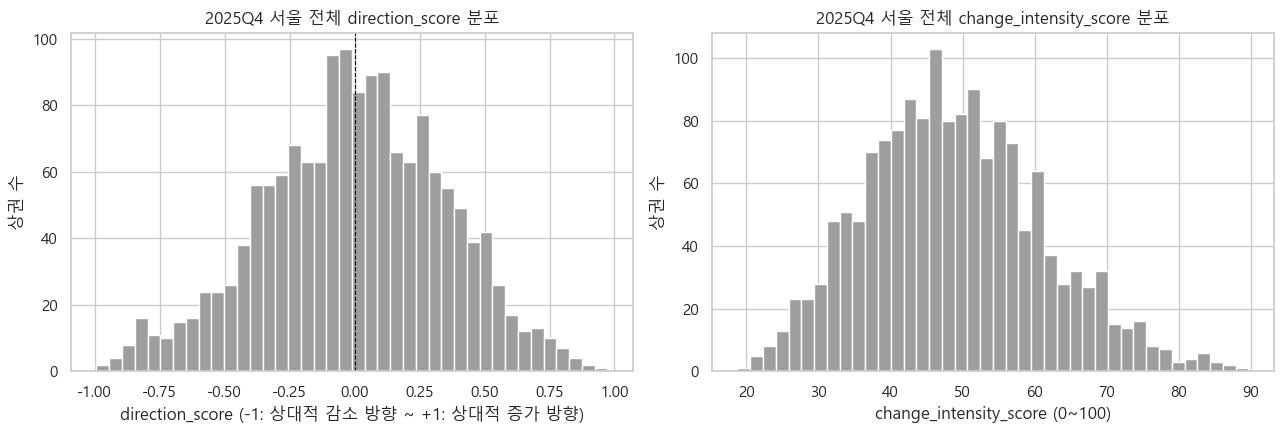

[direction_score 요약]
count    1557.000000
mean        0.000027
std         0.352732
min        -0.993438
25%        -0.236340
50%         0.003363
75%         0.248900
max         0.972930
Name: direction_score, dtype: float64

[change_intensity_score 요약]
count    1557.000000
mean       48.806009
std        12.321361
min        18.756558
25%        39.991231
50%        48.168077
75%        56.534975
max        89.666963
Name: change_intensity_score, dtype: float64


In [13]:
latest_signals = signals[signals["기준_년분기_코드"] == LATEST_QUARTER]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(latest_signals["direction_score"].dropna(), bins=40, color=SEOUL_COLOR)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} 서울 전체 direction_score 분포")
axes[0].set_xlabel("direction_score (-1: 상대적 감소 방향 ~ +1: 상대적 증가 방향)")
axes[0].set_ylabel("상권 수")

axes[1].hist(latest_signals["change_intensity_score"].dropna(), bins=40, color=SEOUL_COLOR)
axes[1].set_title(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} 서울 전체 change_intensity_score 분포")
axes[1].set_xlabel("change_intensity_score (0~100)")
axes[1].set_ylabel("상권 수")

plt.tight_layout()
plt.show()

print("[direction_score 요약]")
print(latest_signals["direction_score"].describe())
print("\n[change_intensity_score 요약]")
print(latest_signals["change_intensity_score"].describe())

## 13. 황학동 direction x change intensity

이번 노트북의 핵심 결과 중 하나다. 최신 분기 서울 전체 상권을 `x=direction_score`, `y=change_intensity_score` 평면에 놓고, 황학 4개 상권의 위치를 강조·주석 표시한다.

네 영역은 다음과 같이 개념적으로 읽을 수 있다(단, 이는 객관적 정답 label이 아니라 해석을 돕기 위한 참고 구획이다).

- **우상단**: 서울 대비 상대적 증가 방향이면서 동시에 구조/괴리/변동성 변화가 큰 상권
- **좌상단**: 서울 대비 상대적 감소 방향이면서 동시에 변화가 큰 상권
- **우하단**: 비교적 안정적인 상대적 증가 방향
- **좌하단**: 비교적 안정적인 상대적 감소 방향

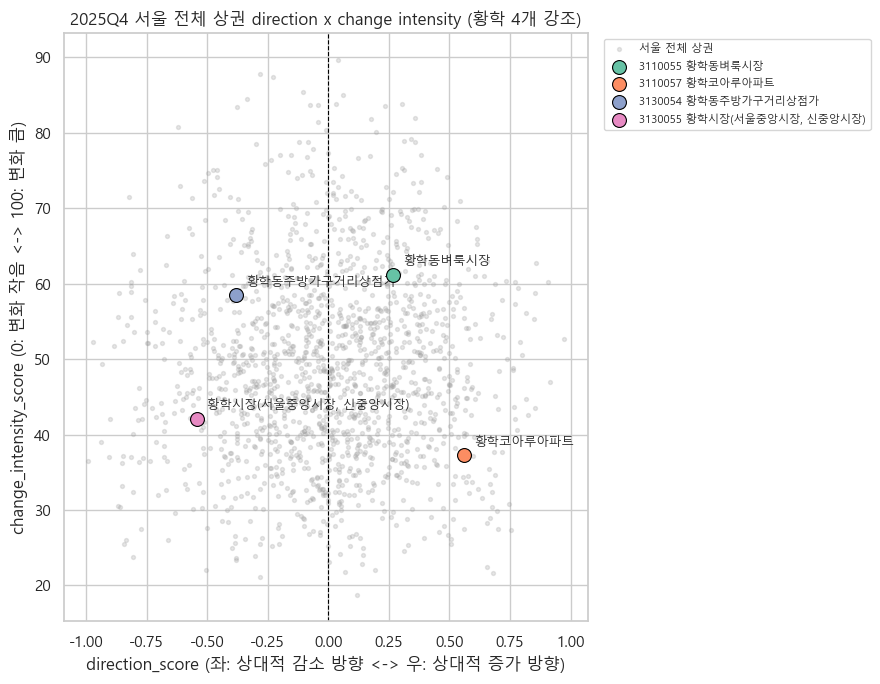

In [14]:
hwanghak_latest = latest_signals[latest_signals["상권_코드"].isin(HWANGHAK_CODES)]
seoul_latest_plot = latest_signals[~latest_signals["상권_코드"].isin(HWANGHAK_CODES)].dropna(
    subset=["direction_score", "change_intensity_score"]
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(seoul_latest_plot["direction_score"], seoul_latest_plot["change_intensity_score"],
           s=8, alpha=0.25, color=SEOUL_COLOR, label="서울 전체 상권")

for i, code_ in enumerate(HWANGHAK_CODES):
    row = hwanghak_latest[hwanghak_latest["상권_코드"] == code_]
    if len(row) == 0 or row[["direction_score", "change_intensity_score"]].isna().any(axis=1).iloc[0]:
        continue
    ax.scatter(row["direction_score"], row["change_intensity_score"], s=100, color=AREA_PALETTE[i],
               edgecolor="black", linewidth=0.8, zorder=5,
               label=f"{code_} {row['상권_코드_명'].iloc[0]}")
    ax.annotate(row["상권_코드_명"].iloc[0],
                (row["direction_score"].iloc[0], row["change_intensity_score"].iloc[0]),
                textcoords="offset points", xytext=(7, 7), fontsize=9)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("direction_score (좌: 상대적 감소 방향 <-> 우: 상대적 증가 방향)")
ax.set_ylabel("change_intensity_score (0: 변화 작음 <-> 100: 변화 큼)")
ax.set_title(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} 서울 전체 상권 direction x change intensity (황학 4개 강조)")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 14. Isolation Forest 입력 feature 선정

Isolation Forest는 이번 프로젝트에서 AI가 실제 분석 역할을 수행하는 첫 단계다. **서울 대부분의 상권과 비교했을 때 변화 패턴이 특이한 상권**을 탐지하는 것이 목적이며, 결과를 "쇠퇴 확률"이라 부르지 않고 "anomaly score / change anomaly / 이상 변화 신호"라고 부른다.

71개 feature를 모두 넣지 않고, 섹션 7~10에서 만든 signal 구성요소 중 **일반적인(=domain-informed가 아닌) 것만** 약 8~15개 선택한다. 상권명/상권코드/황학동 여부 같은 식별자와 `furniture_sales_share`/`korean_food_sales_share`/`ecommerce_sales_share`(EDA 기반 domain-informed feature)는 제외한다. raw/log/percentile을 중복으로 넣지 않기 위해, 모두 **동일 분기 percentile 또는 percentile 기반 gap**으로 통일한다.

| feature | 선택 이유 | 신호 의미 |
|---|---|---|
| `sales_yoy_percentile` | 매출 변화의 대표 지표(percentile, 극단값에 안정적) | 매출 변화 방향/크기의 서울 내 상대적 위치 |
| `transactions_yoy_percentile` | 거래 변화의 대표 지표 | 거래건수 변화의 서울 내 상대적 위치 |
| `stores_yoy_percentile` | 점포 변화의 대표 지표 | 점포 수 변화의 서울 내 상대적 위치 |
| `population_yoy_percentile` | 유동인구 변화의 대표 지표 | 유동인구 변화의 서울 내 상대적 위치 |
| `weekend_share_yoy_change_abs_percentile` | 주말 소비 구조 변화(섹션 8) | 주말 매출 비중 변화 강도의 상대적 위치 |
| `evening_share_yoy_change_abs_percentile` | 저녁/야간 소비 구조 변화(섹션 8) | 저녁·야간 매출 비중 변화 강도의 상대적 위치 |
| `industry_hhi_yoy_change_abs_percentile` | 업종 집중도 변화(섹션 8) | 업종 매출 집중도 변화 강도의 상대적 위치 |
| `sales_4q_cv_percentile` | 매출 변동성(섹션 10) | 최근 4분기 매출 변동성의 상대적 위치 |
| `closing_intensity_percentile` | 개업/폐업 강도 중 폐업(섹션 10) | 폐업 강도의 상대적 위치 |
| `sales_population_yoy_percentile_gap` | 매출-유동인구 YoY 괴리(섹션 9, signed) | 매출 변화와 유동인구 변화의 서울 내 상대적 위치 차이 |
| `sales_store_yoy_percentile_gap` | 매출-점포 YoY 괴리(섹션 9, signed) | 매출 변화와 점포수 변화의 서울 내 상대적 위치 차이 |

이 조합의 정확한 feature 수는 아래 코드 셀에서 `len(AI_FEATURE_COLS)`로 직접 확인하며, "8~15개의 해석 가능한 핵심 feature" 목표 범위 안에 있는지도 함께 검증한다. 괴리 2개는 이상탐지에 방향 정보가 남아있는 것이 더 유용하다고 판단해 signed 값을 그대로 사용했다(부호가 있어도 Isolation Forest는 각 축의 분포 전반에서 특이한 조합을 탐지하므로 문제가 되지 않는다). **섹션 9에서 확인했듯 `sales_population_percentile_gap`/`sales_store_percentile_gap`(레벨 gap)은 여기 포함하지 않는다** — 절대 규모의 차이일 뿐 변화의 엇갈림을 나타내지 않기 때문이다.

In [15]:
AI_FEATURE_COLS = [
    "sales_yoy_percentile",
    "transactions_yoy_percentile",
    "stores_yoy_percentile",
    "population_yoy_percentile",
    "weekend_share_yoy_change_abs_percentile",
    "evening_share_yoy_change_abs_percentile",
    "industry_hhi_yoy_change_abs_percentile",
    "sales_4q_cv_percentile",
    "closing_intensity_percentile",
    "sales_population_yoy_percentile_gap",
    "sales_store_yoy_percentile_gap",
]
assert all(c in signals.columns for c in AI_FEATURE_COLS), "AI_FEATURE_COLS 중 signals에 없는 컬럼이 있습니다."

EXCLUDED_DOMAIN_COLS = ["furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share"]

print("Isolation Forest 입력 feature 수:", len(AI_FEATURE_COLS))
for c in AI_FEATURE_COLS:
    print(" -", c)
print(f"\n목표 범위(8~15개) 충족 여부: {8 <= len(AI_FEATURE_COLS) <= 15}")
print("제외한 domain-informed feature(황학동 해석 전용, 섹션 26):", EXCLUDED_DOMAIN_COLS)

signals["if_input_complete"] = signals[AI_FEATURE_COLS].notna().all(axis=1)
print("\nsignal_eligible 내 AI 입력 feature 완전성 비율:",
      round(signals.loc[signals["signal_eligible"], "if_input_complete"].mean() * 100, 2), "%")

Isolation Forest 입력 feature 수: 11
 - sales_yoy_percentile
 - transactions_yoy_percentile
 - stores_yoy_percentile
 - population_yoy_percentile
 - weekend_share_yoy_change_abs_percentile
 - evening_share_yoy_change_abs_percentile
 - industry_hhi_yoy_change_abs_percentile
 - sales_4q_cv_percentile
 - closing_intensity_percentile
 - sales_population_yoy_percentile_gap
 - sales_store_yoy_percentile_gap

목표 범위(8~15개) 충족 여부: True
제외한 domain-informed feature(황학동 해석 전용, 섹션 26): ['furniture_sales_share', 'korean_food_sales_share', 'ecommerce_sales_share']

signal_eligible 내 AI 입력 feature 완전성 비율: 99.35 %


## 15. 분기별 Isolation Forest

각 분기별로 **서울 상대 이상성**을 탐지한다: 2022Q1 서울 상권으로 2022Q1 모델을 학습하고, 2022Q2는 별도로 2022Q2 모델을 학습하는 방식이다. 이렇게 하면 "이상하다"는 판단이 항상 같은 시점 서울 상권 대비로만 이뤄지며, 서로 다른 경기 국면의 분기를 직접 비교하지 않는다는 노트북 전체 원칙과 일치한다.

각 분기에서: (1) `signal_eligible & if_input_complete`인 행만 사용, (2) 황학 4개 상권은 reference fit에서 제외, (3) 나머지 서울 상권으로 `IsolationForest`를 학습, (4) 그 분기의 모든 eligible 상권(황학 포함)에 대해 score를 계산한다. 황학이 1,650개 중 일부라 결과 차이가 크지 않더라도, "서울 일반 상권을 기준으로 황학동을 사후 평가한다"는 분석 논리를 지키기 위해 fit에서는 명시적으로 제외한다.

**Scaling**: `RobustScaler`를 사용한다. 단, Isolation Forest는 KMeans 같은 거리 기반 모델이 아니라 각 feature 축을 무작위로 분할해 몇 번 만에 데이터를 고립시키는지를 보는 트리 기반 모델이므로, "변수 단위가 다르기 때문에 반드시 scaling이 필요하다"는 설명은 정확하지 않다. 여기서 `RobustScaler`를 쓰는 이유는 (1) 섹션 18 이후 KMeans에서도 동일한 scaler를 사용해 **전처리 파이프라인의 일관성**을 유지하고, (2) 앞서 확인한 것처럼 서울 상권 데이터에는 극단적인 YoY 값이 존재할 수 있어 중앙값/IQR 기반으로 **입력 표현 자체의 극단값 영향을 완화**하기 위함이다. scaler는 **reference(서울-황학)로만 fit**한 뒤 황학을 포함한 모든 대상에 transform한다.

**하이퍼파라미터**: `random_state=42`로 고정하고 `n_estimators=200`은 기본값보다 다소 높여 안정성을 확보하되 과도한 튜닝은 하지 않는다. `contamination=0.05`로 설정하지만, 이번 노트북에서는 `IsolationForest.score_samples()`(값이 낮을수록 더 이상함)만 사용해 `anomaly_score = -score_samples()`를 만들고 이를 다시 percentile화하므로, **`contamination`은 `predict()`/`decision_function()`의 판정 임계값에만 영향을 주고 실제로 사용하는 `anomaly_score`/`anomaly_percentile` 순위 자체에는 영향을 주지 않는다.** 정답 label이 없으므로 이 값을 "성능이 좋아지는 방향"으로 튜닝하지 않았다.

In [16]:
IF_CONTAMINATION = 0.05
IF_N_ESTIMATORS = 200

anomaly_records = []
quarter_sample_log = []

for quarter in QUARTER_ORDER:
    if quarter < ANALYSIS_START_QUARTER:
        continue

    q_mask = (signals["기준_년분기_코드"] == quarter) & signals["signal_eligible"] & signals["if_input_complete"]
    q_idx = signals.index[q_mask]
    if len(q_idx) == 0:
        continue

    is_hwanghak = signals.loc[q_idx, "상권_코드"].isin(HWANGHAK_CODES).to_numpy()
    reference_idx = q_idx[~is_hwanghak]
    hwanghak_idx = q_idx[is_hwanghak]

    X_reference = signals.loc[reference_idx, AI_FEATURE_COLS].to_numpy()
    scaler = RobustScaler()
    X_reference_scaled = scaler.fit_transform(X_reference)

    model = IsolationForest(
        n_estimators=IF_N_ESTIMATORS, contamination=IF_CONTAMINATION, random_state=RANDOM_STATE
    )
    model.fit(X_reference_scaled)

    X_all_scaled = scaler.transform(signals.loc[q_idx, AI_FEATURE_COLS].to_numpy())
    anomaly_score = -model.score_samples(X_all_scaled)

    anomaly_records.append(pd.DataFrame({
        "기준_년분기_코드": quarter,
        "상권_코드": signals.loc[q_idx, "상권_코드"].to_numpy(),
        "anomaly_score": anomaly_score,
    }))
    quarter_sample_log.append({
        "기준_년분기_코드": quarter, "분기_라벨": QUARTER_LABEL_MAP[quarter],
        "reference_n": len(reference_idx), "hwanghak_n": len(hwanghak_idx),
    })

anomaly_df = pd.concat(anomaly_records, ignore_index=True)
quarter_sample_df = pd.DataFrame(quarter_sample_log)

signals = signals.merge(anomaly_df, on=["기준_년분기_코드", "상권_코드"], how="left")
assert not signals.duplicated(subset=["기준_년분기_코드", "상권_코드"]).any(), "merge 후 grain에 중복이 생겼습니다."

print("Isolation Forest 학습 분기 수:", quarter_sample_df.shape[0])
print("\n분기별 reference(서울-황학) / 황학 표본 수:")
quarter_sample_df

Isolation Forest 학습 분기 수: 16

분기별 reference(서울-황학) / 황학 표본 수:


,기준_년분기_코드,분기_라벨,reference_n,hwanghak_n
0,20221,2022Q1,1558,4
1,20222,2022Q2,1561,4
2,20223,2022Q3,1557,4
3,20224,2022Q4,1555,4
4,20231,2023Q1,1556,4
5,20232,2023Q2,1557,4
6,20233,2023Q3,1557,4
7,20234,2023Q4,1556,4
8,20241,2024Q1,1558,4
9,20242,2024Q2,1557,4


## 16. anomaly score / percentile

`anomaly_score`는 값이 높을수록 더 특이한 변화를 의미하도록 정의했다(`-score_samples()`). 이를 다시 동일 분기 서울 전체 내 percentile로 변환해 `anomaly_percentile`을 만든다. 예: 95면 "같은 분기 서울 상권 중 약 상위 5% 수준으로 특이한 변화"라는 뜻이다.

`anomaly_percentile >= 95`인 행을 `attention_flag`로 표시하지만, 이는 실제 쇠퇴 label이 아니라 **분석 편의를 위한 attention threshold**임을 다시 명시한다.

In [17]:
signals["anomaly_percentile"] = seoul_percentile(signals, "anomaly_score")

ATTENTION_PERCENTILE_THRESHOLD = 95
signals["attention_flag"] = signals["anomaly_percentile"] >= ATTENTION_PERCENTILE_THRESHOLD
signals.loc[signals["anomaly_score"].isna(), "attention_flag"] = False

print("anomaly_percentile 계산 완료(같은 분기, 같은 모델로 산출된 anomaly_score 기준)")
print("attention_flag=True 행 수:", int(signals["attention_flag"].sum()))
print(f"(attention_flag는 같은 분기 서울 상권 중 상위 {100 - ATTENTION_PERCENTILE_THRESHOLD}% 수준의 이상 변화를 표시하는",
      "분석 편의용 threshold이며, 쇠퇴 판정이 아니다.)")

latest_anomaly = signals[signals["기준_년분기_코드"] == LATEST_QUARTER].dropna(subset=["anomaly_percentile"])
print(f"\n[{QUARTER_LABEL_MAP[LATEST_QUARTER]} anomaly_percentile 상위 10개 상권]")
latest_anomaly.nlargest(10, "anomaly_percentile")[
    ["상권_코드", "상권_코드_명", "anomaly_score", "anomaly_percentile"]
].reset_index(drop=True)

anomaly_percentile 계산 완료(같은 분기, 같은 모델로 산출된 anomaly_score 기준)
attention_flag=True 행 수: 1241
(attention_flag는 같은 분기 서울 상권 중 상위 5% 수준의 이상 변화를 표시하는 분석 편의용 threshold이며, 쇠퇴 판정이 아니다.)

[2025Q4 anomaly_percentile 상위 10개 상권]


,상권_코드,상권_코드_명,anomaly_score,anomaly_percentile
0,3130127,석관시장,0.636382,99.935691
1,3130296,남부종합시장,0.623039,99.871383
2,3130108,태능엔터피아(태릉시장),0.614429,99.807074
3,3110238,배꽃어린이공원,0.613185,99.742765
4,3130321,장신구 특화거리 상점가,0.609764,99.678457
5,3110799,영등포본동주민센터,0.609627,99.614148
6,3110208,시조사삼거리,0.609539,99.549839
7,3130103,이경시장,0.606648,99.485531
8,3110628,신목동역,0.605289,99.421222
9,3130224,개봉프라자(고척근린시장),0.604260,99.356913


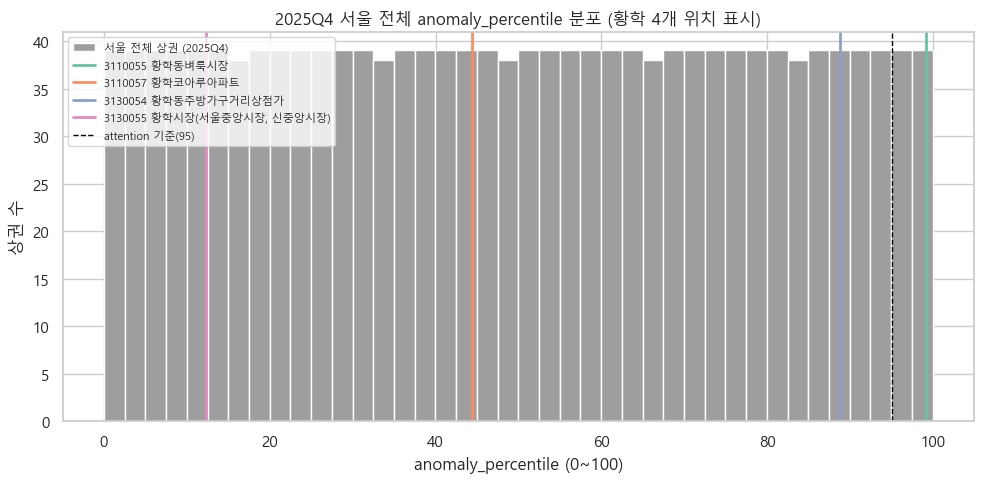

In [18]:
# 필수 시각화: 최신 분기 anomaly percentile 서울 분포 + 황학 4개 위치
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(latest_anomaly["anomaly_percentile"], bins=40, color=SEOUL_COLOR,
        label=f"서울 전체 상권 ({QUARTER_LABEL_MAP[LATEST_QUARTER]})")

hwanghak_anomaly_latest = latest_anomaly[latest_anomaly["상권_코드"].isin(HWANGHAK_CODES)]
for i, code_ in enumerate(HWANGHAK_CODES):
    row = hwanghak_anomaly_latest[hwanghak_anomaly_latest["상권_코드"] == code_]
    if len(row) == 0:
        continue
    ax.axvline(row["anomaly_percentile"].iloc[0], color=AREA_PALETTE[i], linewidth=2,
               label=f"{code_} {row['상권_코드_명'].iloc[0]}")

ax.axvline(ATTENTION_PERCENTILE_THRESHOLD, color="black", linestyle="--", linewidth=1,
           label=f"attention 기준({ATTENTION_PERCENTILE_THRESHOLD})")
ax.set_xlabel("anomaly_percentile (0~100)")
ax.set_ylabel("상권 수")
ax.set_title(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} 서울 전체 anomaly_percentile 분포 (황학 4개 위치 표시)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 17. anomaly 해석용 feature deviation

Isolation Forest가 "이상하다"고 판단했다는 결과만 보여주지 않는다. 황학 4개 상권 각각에 대해, 해당 분기 서울 상권(reference, eligible) 분포와 비교해 **어떤 feature가 특히 특이했는지**를 확인한다. 서울 median 대비 차이, 서울 percentile, robust z-score(median/MAD 기반, 이상치에 덜 민감)를 계산해 각 상권의 Top unusual feature 3~5개를 보여준다.

이는 Isolation Forest의 엄밀한 feature importance가 아니라 **anomaly 결과를 해석하기 위한 보조적인 feature deviation 분석**이다.

In [19]:
def compute_feature_deviation(df, quarter, area_code, feature_cols):
    q_df = df[(df["기준_년분기_코드"] == quarter) & df["signal_eligible"] & df["if_input_complete"]]
    area_row = q_df[q_df["상권_코드"] == area_code]
    if len(area_row) == 0:
        return pd.DataFrame()

    rows = []
    for col in feature_cols:
        seoul_values = q_df[col].dropna()
        area_value = area_row[col].iloc[0]
        median = seoul_values.median()
        mad = (seoul_values - median).abs().median()
        robust_z = (area_value - median) / (1.4826 * mad) if mad > 0 else np.nan
        pct = float((seoul_values < area_value).mean() * 100)
        rows.append({
            "feature": col, "area_value": area_value, "seoul_median": median,
            "seoul_percentile": pct, "robust_z": robust_z,
        })
    out = pd.DataFrame(rows)
    out["abs_robust_z"] = out["robust_z"].abs()
    return out.sort_values("abs_robust_z", ascending=False)


for code_ in HWANGHAK_CODES:
    name_ = features.loc[features["상권_코드"] == code_, "상권_코드_명"].iloc[0]
    dev = compute_feature_deviation(signals, LATEST_QUARTER, code_, AI_FEATURE_COLS)
    print(f"\n[{code_} {name_}] {QUARTER_LABEL_MAP[LATEST_QUARTER]} 기준 Top unusual features (보조적 해석)")
    if len(dev) == 0:
        print(" - 해당 분기 AI 입력 feature가 불완전하여 계산할 수 없습니다.")
        continue
    display(dev.head(5).round(2))


[3110055 황학동벼룩시장] 2025Q4 기준 Top unusual features (보조적 해석)


,feature,area_value,seoul_median,seoul_percentile,robust_z,abs_robust_z
9,sales_population_yoy_percentile_gap,94.61,0.19,99.68,2.40,2.40
5,evening_share_yoy_change_abs_percentile,99.94,49.90,99.94,1.35,1.35
4,weekend_share_yoy_change_abs_percentile,99.94,49.90,99.94,1.35,1.35
7,sales_4q_cv_percentile,99.49,49.87,99.49,1.34,1.34
3,population_yoy_percentile,2.25,50.12,1.93,-1.32,1.32



[3110057 황학코아루아파트] 2025Q4 기준 Top unusual features (보조적 해석)


,feature,area_value,seoul_median,seoul_percentile,robust_z,abs_robust_z
5,evening_share_yoy_change_abs_percentile,1.92,49.90,1.93,-1.30,1.30
1,transactions_yoy_percentile,89.29,49.97,89.32,1.06,1.06
0,sales_yoy_percentile,80.05,49.97,80.13,0.81,0.81
3,population_yoy_percentile,75.30,50.12,75.82,0.69,0.69
4,weekend_share_yoy_change_abs_percentile,74.60,49.90,74.66,0.67,0.67



[3130054 황학동주방가구거리상점가] 2025Q4 기준 Top unusual features (보조적 해석)


,feature,area_value,seoul_median,seoul_percentile,robust_z,abs_robust_z
10,sales_store_yoy_percentile_gap,-73.35,-0.59,3.09,-2.06,2.06
6,industry_hhi_yoy_change_abs_percentile,93.39,49.90,93.44,1.18,1.18
2,stores_yoy_percentile,89.52,50.12,89.84,1.18,1.18
3,population_yoy_percentile,8.86,50.12,8.23,-1.14,1.14
1,transactions_yoy_percentile,9.56,49.97,9.45,-1.09,1.09



[3130055 황학시장(서울중앙시장, 신중앙시장)] 2025Q4 기준 Top unusual features (보조적 해석)


,feature,area_value,seoul_median,seoul_percentile,robust_z,abs_robust_z
3,population_yoy_percentile,13.17,50.12,12.48,-1.02,1.02
0,sales_yoy_percentile,13.02,49.97,12.93,-1.00,1.00
10,sales_store_yoy_percentile_gap,-33.10,-0.59,18.14,-0.92,0.92
1,transactions_yoy_percentile,19.37,49.97,19.29,-0.83,0.83
5,evening_share_yoy_change_abs_percentile,76.52,49.90,76.66,0.72,0.72


### Anomaly Driver (Top Abnormal Input Features) — 최종 산출물로 저장

바로 위 `compute_feature_deviation()`은 화면 출력(탐색적 분석)에 그쳤다. 여기서는 같은 목적을 **percentile 기반 규칙으로 명확히 정의**해 최종 산출물(`hwanghak_anomaly_drivers.csv`)까지 저장하고, `07_strategy_recommendation.ipynb`을 거쳐 `hwanghak_strategy_recommendation.csv`까지 전달한다.

**정의**: `Anomaly Driver`(Top Abnormal Input Features)는 `AI_FEATURE_COLS`(Isolation Forest 입력 11개) 중, 같은 분기 서울 상권 분포에서 해당 상권의 **입력값 자체가 얼마나 극단적인 위치에 있는지**를 percentile로 요약한 것이다.

> **이것은 Isolation Forest의 feature importance/model attribution이 아니다.** Isolation Forest는 "이 판정에 각 feature가 얼마나 기여했는가"를 직접 제공하지 않으며, 이 노트북은 SHAP 등으로 그런 기여도를 새로 만들어내지 않는다. `Anomaly Driver`는 "왜 모델이 이 상권을 이상하다고 판단했는가"에 대한 모델 내부의 설명이 아니라, "이 상권의 입력 feature 중 어떤 것이 서울 분포에서 특히 극단적인 값을 가지는가"라는 **입력값 자체의 이상성(input abnormality)**을 설명하는 보조 지표다. anomaly_percentile이 높다고 해서 여기서 Top으로 뽑힌 feature가 그 판정의 "원인"이라고 단정하지 않는다.

**계산 방법**:
1. `AI_FEATURE_COLS` 11개 중 9개(`sales_yoy_percentile` 등)는 이미 그 자체로 같은 분기 서울 전체 상권 `seoul_percentile()` 값이므로 **다시 percentile로 변환하지 않고** 그대로 재사용한다(아래 코드의 `ANOMALY_DRIVER_PERCENTILE_MAP`에서 `{col: col}`로 매핑되어, 이미 percentile인 값을 또 rank화하는 이중 변환이 일어나지 않음을 확인할 수 있다).
2. 나머지 2개(`sales_population_yoy_percentile_gap`, `sales_store_yoy_percentile_gap`)는 percentile "차이" 값이라 그 자체가 0~100 percentile이 아니므로(실제 관측 범위도 약 -99~+99로 percentile과 다름), 같은 `seoul_percentile()` 기준으로 그 값 자체의 percentile을 새로 계산한다(9개와 동일한 계산 방식을 재사용하는 것이며 새로운 통계 방법을 도입하지 않는다).
3. `extremeness = abs(percentile - 50)`로 정의한다 — percentile 50(서울 중앙값과 동일)은 극단성 0, 0 또는 100에 가까울수록 극단적이다.
4. 황학 4개 상권 각각에 대해 `extremeness`가 큰 순서로 Top 3 feature를 선택하고, `percentile > 50`이면 `HIGH`(서울 대비 높은 쪽 극단), `percentile < 50`이면 `LOW`(낮은 쪽 극단)로 `direction`을 표시한다. **`HIGH`/`LOW`는 "좋음/나쁨"이 아니라 서울 분포 상단/하단 극단에 위치한다는 뜻일 뿐이다.** 특히 `weekend_share_yoy_change_abs_percentile`처럼 절댓값(변화의 크기)을 percentile화한 feature는 `HIGH`가 "변화 폭이 크다"는 뜻일 뿐 그 변화가 긍정적/부정적인지는 알려주지 않는다.

**Feature별 유형 확인**(정의는 섹션 14 표 참고, 아래는 실측 범위 기준 재확인):

| feature | 이미 percentile인가? | 실측 범위(commercial_signals.csv) | Anomaly Driver에서 사용되는 값 |
|---|---|---|---|
| `sales_yoy_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `transactions_yoy_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `stores_yoy_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `population_yoy_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `weekend_share_yoy_change_abs_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `evening_share_yoy_change_abs_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `industry_hhi_yoy_change_abs_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `sales_4q_cv_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `closing_intensity_percentile` | Yes | 0~100 | 원래 값 그대로 사용 |
| `sales_population_yoy_percentile_gap` | **No**(percentile 간 차이) | 약 -99~+99 | `seoul_percentile()`로 이 gap 값 자체를 재percentile화한 뒤 사용 |
| `sales_store_yoy_percentile_gap` | **No**(percentile 간 차이) | 약 -99~+99 | `seoul_percentile()`로 이 gap 값 자체를 재percentile화한 뒤 사용 |

이 결과는 `commercial_signals.csv`(33,000행, 서울 전체 grain)를 수정하지 않고, 06의 `hwanghak_peer_benchmark.csv`와 같은 방식으로 **별도 파일** `hwanghak_anomaly_drivers.csv`(황학 4개 상권 x 1행, `LATEST_QUARTER` 기준)로 저장한다.


In [20]:
# TYPE A: 이미 같은 분기 서울 전체 상권 기준 0~100 percentile인 feature(04/05의 seoul_percentile() 결과).
# Anomaly Driver에서 다시 percentile rank를 계산하지 않고 원래 값을 그대로 재사용한다(이중 percentile 변환 방지).
PERCENTILE_FEATURES = [
    "sales_yoy_percentile",
    "transactions_yoy_percentile",
    "stores_yoy_percentile",
    "population_yoy_percentile",
    "weekend_share_yoy_change_abs_percentile",
    "evening_share_yoy_change_abs_percentile",
    "industry_hhi_yoy_change_abs_percentile",
    "sales_4q_cv_percentile",
    "closing_intensity_percentile",
]

# TYPE B: 두 percentile 값의 차이(gap)로 만들어진 feature. 값 자체가 0~100 percentile이 아니므로
# (실측 범위 약 -99~+99), 같은 seoul_percentile() 기준으로 gap 값 자체의 percentile을 새로 계산한다.
PERCENTILE_GAP_FEATURES = [
    "sales_population_yoy_percentile_gap",
    "sales_store_yoy_percentile_gap",
]

# 현재 AI_FEATURE_COLS 11개는 TYPE A(9) + TYPE B(2)로 전부 분류되며, raw value 형태의 TYPE C는 없다.
assert set(PERCENTILE_FEATURES) | set(PERCENTILE_GAP_FEATURES) == set(AI_FEATURE_COLS), (
    "PERCENTILE_FEATURES + PERCENTILE_GAP_FEATURES가 AI_FEATURE_COLS 11개와 정확히 일치해야 합니다."
)
assert not (set(PERCENTILE_FEATURES) & set(PERCENTILE_GAP_FEATURES)), "TYPE A/B 분류가 겹치면 안 됩니다."

# Reference pool 선택: Isolation Forest는 분기별로 황학 4개 상권을 제외한 서울 상권만 reference fit에
# 사용하지만, 이는 "평가 대상 데이터로 모델을 학습하지 않는다"는 모델 적합(fit) 고유의 원칙이다. TYPE A
# 9개의 percentile은 애초에 04/05에서 "서울 전체(황학 포함)" 기준으로 계산되어 있고, 이는 direction_score/
# structural_change_score 등 이번에 변경하지 않는 기존 Signal 전체가 공유하는 정의다. 같은 Top 3 안에서
# TYPE B만 황학 제외 기준으로 새로 계산하면 TYPE A/B가 서로 다른 reference 모집단을 쓰게 되어 오히려
# 일관성이 깨진다. 실측으로도 황학 포함/제외 percentile 차이는 4/1,650행 기준 0.13%p 이내로 무시할
# 수준임을 확인했다(Top 3 선정·direction 판정에 영향 없음). 따라서 TYPE B도 TYPE A와 동일하게 "서울
# 전체" 기준 seoul_percentile()을 사용한다.
signals["sales_population_yoy_percentile_gap_pct"] = seoul_percentile(signals, "sales_population_yoy_percentile_gap")
signals["sales_store_yoy_percentile_gap_pct"] = seoul_percentile(signals, "sales_store_yoy_percentile_gap")

ANOMALY_DRIVER_PERCENTILE_MAP = {col: col for col in PERCENTILE_FEATURES}
ANOMALY_DRIVER_PERCENTILE_MAP.update({col: f"{col}_pct" for col in PERCENTILE_GAP_FEATURES})

# TYPE 분류가 실제 매핑에 정확히 반영됐는지 구조적으로 확인한다(값 비교가 아니라 매핑 자체를 검증).
for _feat in PERCENTILE_FEATURES:
    assert ANOMALY_DRIVER_PERCENTILE_MAP[_feat] == _feat, (
        f"{_feat}(TYPE A)가 원래 컬럼이 아닌 다른 컬럼으로 매핑되어 있습니다 — 불필요한 재계산이 의심됩니다."
    )
for _feat in PERCENTILE_GAP_FEATURES:
    assert ANOMALY_DRIVER_PERCENTILE_MAP[_feat] == f"{_feat}_pct", (
        f"{_feat}(TYPE B)가 원래 gap 컬럼을 그대로 percentile로 사용하고 있습니다 — 재percentile화가 빠졌습니다."
    )

ANOMALY_DRIVER_TOP_N = 3


def compute_anomaly_drivers(df, quarter, area_code, feature_cols, percentile_map, top_n=ANOMALY_DRIVER_TOP_N):
    """AI_FEATURE_COLS 중 서울 상권 분포에서 percentile 기준으로 가장 극단적인 Top N feature를 반환한다.

    주의: 이는 Isolation Forest의 feature importance/model attribution이 아니라, 입력 feature 자체가
    서울 분포 내에서 얼마나 극단적인 값을 가지는지(input abnormality)를 percentile로 요약한 보조 지표다.
    """
    row = df[(df["기준_년분기_코드"] == quarter) & (df["상권_코드"] == area_code)]
    if len(row) == 0:
        return []
    row = row.iloc[0]

    records = []
    for col in feature_cols:
        pct = row[percentile_map[col]]
        if pd.isna(pct):
            continue
        pct = float(pct)
        direction = "HIGH" if pct > 50 else ("LOW" if pct < 50 else "TYPICAL")
        records.append({"feature": col, "percentile": pct, "direction": direction, "extremeness": abs(pct - 50)})
    records.sort(key=lambda r: r["extremeness"], reverse=True)
    return records[:top_n]


anomaly_driver_rows = []
for code_ in HWANGHAK_CODES:
    name_ = features.loc[features["상권_코드"] == code_, "상권_코드_명"].iloc[0]
    type_ = features.loc[features["상권_코드"] == code_, "상권_구분_코드_명"].iloc[0]
    drivers = compute_anomaly_drivers(signals, LATEST_QUARTER, code_, AI_FEATURE_COLS, ANOMALY_DRIVER_PERCENTILE_MAP)

    row = {
        "기준_년분기_코드": LATEST_QUARTER,
        "분기_라벨": QUARTER_LABEL_MAP[LATEST_QUARTER],
        "상권_코드": code_,
        "상권_코드_명": name_,
        "상권_구분_코드_명": type_,
    }
    for i in range(ANOMALY_DRIVER_TOP_N):
        if i < len(drivers):
            d = drivers[i]
            row[f"anomaly_driver_{i + 1}"] = d["feature"]
            row[f"anomaly_driver_{i + 1}_percentile"] = round(d["percentile"], 2)
            row[f"anomaly_driver_{i + 1}_direction"] = d["direction"]
            row[f"anomaly_driver_{i + 1}_extremeness"] = round(d["extremeness"], 2)
        else:
            row[f"anomaly_driver_{i + 1}"] = np.nan
            row[f"anomaly_driver_{i + 1}_percentile"] = np.nan
            row[f"anomaly_driver_{i + 1}_direction"] = np.nan
            row[f"anomaly_driver_{i + 1}_extremeness"] = np.nan
    anomaly_driver_rows.append(row)

hwanghak_anomaly_drivers = pd.DataFrame(anomaly_driver_rows)

assert len(hwanghak_anomaly_drivers) == len(HWANGHAK_CODES), "황학 4개 상권 모두에 대해 anomaly driver 행이 생성되어야 합니다."
driver_name_cols = [f"anomaly_driver_{i + 1}" for i in range(ANOMALY_DRIVER_TOP_N)]
assert hwanghak_anomaly_drivers[driver_name_cols].notna().all().all(), (
    "황학 4개 상권 중 Top 3 anomaly driver가 모두 채워지지 않은 상권이 있습니다"
    "(해당 분기 AI 입력이 불완전할 가능성이 있습니다)."
)
driver_pct_cols = [f"anomaly_driver_{i + 1}_percentile" for i in range(ANOMALY_DRIVER_TOP_N)]
for c in driver_pct_cols:
    assert hwanghak_anomaly_drivers[c].between(0, 100).all(), f"{c}이 0~100 범위를 벗어났습니다."
driver_dir_cols = [f"anomaly_driver_{i + 1}_direction" for i in range(ANOMALY_DRIVER_TOP_N)]
for c in driver_dir_cols:
    assert hwanghak_anomaly_drivers[c].isin(["HIGH", "LOW", "TYPICAL"]).all(), f"{c}에 알 수 없는 값이 있습니다."

# 추가 검증: Top 3 중복 없음 / extremeness 범위 / TYPE A·B percentile 처리가 최종 산출물에도
# 정확히 반영됐는지(값 수준) 재확인한다.
driver_ext_cols = [f"anomaly_driver_{i + 1}_extremeness" for i in range(ANOMALY_DRIVER_TOP_N)]
for c in driver_ext_cols:
    assert hwanghak_anomaly_drivers[c].between(0, 50).all(), f"{c}가 0~50 범위를 벗어났습니다."

for _, _r in hwanghak_anomaly_drivers.iterrows():
    _names = [_r[c] for c in driver_name_cols]
    assert len(set(_names)) == len(_names), f"{_r['상권_코드_명']}의 Top 3 Driver에 중복 feature가 있습니다."

_latest_by_code = signals[signals["기준_년분기_코드"] == LATEST_QUARTER].set_index("상권_코드")
for _, _r in hwanghak_anomaly_drivers.iterrows():
    _code = int(_r["상권_코드"])
    for i in range(1, ANOMALY_DRIVER_TOP_N + 1):
        _feat = _r[f"anomaly_driver_{i}"]
        _pct = _r[f"anomaly_driver_{i}_percentile"]
        if _feat in PERCENTILE_FEATURES:
            _raw = _latest_by_code.loc[_code, _feat]
            assert abs(_raw - _pct) < 0.01, (
                f"{_feat}는 TYPE A인데 driver percentile({_pct})이 원래 값({_raw})과 다릅니다"
                " — 이중 percentile 변환이 의심됩니다."
            )
        elif _feat in PERCENTILE_GAP_FEATURES:
            _raw_gap = _latest_by_code.loc[_code, _feat]
            assert abs(_raw_gap - _pct) > 0.01, (
                f"{_feat}는 TYPE B인데 driver percentile({_pct})이 원래 gap 원값({_raw_gap})과 동일합니다"
                " — percentile 변환이 누락됐을 가능성이 있습니다."
            )

print("hwanghak_anomaly_drivers shape:", hwanghak_anomaly_drivers.shape)
print("Anomaly Driver 추가 검증 통과: Top3 중복 없음 / extremeness 0~50 / TYPE A·B percentile 처리 일관성 확인")
hwanghak_anomaly_drivers


hwanghak_anomaly_drivers shape: (4, 17)
Anomaly Driver 추가 검증 통과: Top3 중복 없음 / extremeness 0~50 / TYPE A·B percentile 처리 일관성 확인


,기준_년분기_코드,분기_라벨,상권_코드,상권_코드_명,상권_구분_코드_명,anomaly_driver_1,anomaly_driver_1_percentile,anomaly_driver_1_direction,anomaly_driver_1_extremeness,anomaly_driver_2,anomaly_driver_2_percentile,anomaly_driver_2_direction,anomaly_driver_2_extremeness,anomaly_driver_3,anomaly_driver_3_percentile,anomaly_driver_3_direction,anomaly_driver_3_extremeness
0,20254,2025Q4,3110055,황학동벼룩시장,골목상권,weekend_share_yoy_change_abs_percentile,99.94,HIGH,49.94,evening_share_yoy_change_abs_percentile,99.94,HIGH,49.94,sales_population_yoy_percentile_gap,99.68,HIGH,49.68
1,20254,2025Q4,3110057,황학코아루아파트,골목상권,evening_share_yoy_change_abs_percentile,1.92,LOW,48.08,transactions_yoy_percentile,89.29,HIGH,39.29,sales_yoy_percentile,80.05,HIGH,30.05
2,20254,2025Q4,3130054,황학동주방가구거리상점가,전통시장,sales_store_yoy_percentile_gap,3.21,LOW,46.79,industry_hhi_yoy_change_abs_percentile,93.39,HIGH,43.39,population_yoy_percentile,8.86,LOW,41.14
3,20254,2025Q4,3130055,"황학시장(서울중앙시장, 신중앙시장)",전통시장,sales_yoy_percentile,13.02,LOW,36.98,population_yoy_percentile,13.17,LOW,36.83,sales_store_yoy_percentile_gap,18.22,LOW,31.78


## 18. 최신 분기 clustering 데이터 구축

Isolation Forest는 "특이함"을 찾지만 "어떤 종류의 상권인가"는 알려주지 않는다. 최신 분기 서울 상권을 대상으로 KMeans clustering을 수행해 변화 유형을 탐색한다.

71개 원본 feature나 Isolation Forest feature를 다시 넣지 않고, 이번 노트북에서 만든 4개 signal(`direction_score`, `structural_change_score`, `decoupling_score`, `instability_score`)만 사용한다. `change_intensity_score`는 **`structural_change_score`, `decoupling_score`, `instability_score`의 평균으로 정의된 값**이므로, 이를 clustering 입력에 함께 넣으면 사실상 같은 정보를 두 번(구성요소 3개 + 그 평균 1개) 입력해 중복 가중치를 주는 문제가 생긴다. 따라서 clustering 입력에서는 제외하고, **cluster 결과를 해석할 때 요약 지표(profile)로만** 별도로 사용한다(섹션 21). 4개 입력 모두 이미 -1~1 또는 0~100 범위의 상대적 지표이므로 절대규모가 군집을 지배하지 않는다.

Isolation Forest와 동일한 논리로, **황학 4개 상권은 fit에서 제외**하고 이후 `predict()`로만 배정한다.

In [21]:
CLUSTER_FEATURE_COLS = [
    "direction_score", "structural_change_score", "decoupling_score", "instability_score",
]
assert "change_intensity_score" not in CLUSTER_FEATURE_COLS, (
    "change_intensity_score는 structural/decoupling/instability의 평균이므로 clustering 입력에서 제외해야 합니다."
)

latest_cluster_base = signals[signals["기준_년분기_코드"] == LATEST_QUARTER].copy()
cluster_ready = latest_cluster_base[CLUSTER_FEATURE_COLS].notna().all(axis=1) & latest_cluster_base["signal_eligible"]
latest_cluster_base["cluster_ready"] = cluster_ready

print("clustering 입력 feature:", CLUSTER_FEATURE_COLS)
print(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} clustering 가능 상권 수:",
      int(cluster_ready.sum()), "/", len(latest_cluster_base))

is_hwanghak_latest = latest_cluster_base["상권_코드"].isin(HWANGHAK_CODES)
reference_cluster_df = latest_cluster_base[cluster_ready & ~is_hwanghak_latest].copy()
hwanghak_cluster_df = latest_cluster_base[cluster_ready & is_hwanghak_latest].copy()

print("reference(서울-황학) 상권 수:", len(reference_cluster_df), "/ 황학 상권 수:", len(hwanghak_cluster_df))

cluster_scaler = RobustScaler()
X_reference_cluster = cluster_scaler.fit_transform(reference_cluster_df[CLUSTER_FEATURE_COLS])
X_hwanghak_cluster = cluster_scaler.transform(hwanghak_cluster_df[CLUSTER_FEATURE_COLS])

clustering 입력 feature: ['direction_score', 'structural_change_score', 'decoupling_score', 'instability_score']
2025Q4 clustering 가능 상권 수: 1557 / 1650
reference(서울-황학) 상권 수: 1553 / 황학 상권 수: 4


## 19. K 선택

`k=4` 같은 값을 하드코딩하지 않는다. reference 상권(황학 제외)에 대해 `k=2~8`을 검토하며 **Silhouette Score**와 **Calinski-Harabasz Score**를 함께 계산한다.

점수가 가장 높은 k를 기계적으로 선택하지 않고, cluster별 sample 수(지나치게 작은 cluster가 생기는지)도 함께 본다. 최고 silhouette 대비 일정 범위(허용오차) 이내이면서 각 cluster 크기가 reference 표본의 일정 비율 이상인 k 중 **가장 작은(단순한) k**를 선택한다.

**해석 시 주의**: Silhouette Score는 이론적으로 -1~1 범위이며, 0.5 이상이어야 군집이 뚜렷하다고 보는 것이 일반적인 경험칙이다. 만약 이 데이터의 Silhouette Score가 0.2~0.3대처럼 낮게 나온다면, 이는 "서울 상권이 명확하게 구분되는 몇 개의 객관적 유형으로 나뉜다"는 뜻이 아니라 **"후보 k 중 상대적으로 가장 나은 분리를 보인 k"** 라는 탐색적 의미로 신중하게 해석한다.

In [22]:
K_RANGE = range(2, 9)
k_scores = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_reference_cluster)
    sil = silhouette_score(X_reference_cluster, labels)
    ch = calinski_harabasz_score(X_reference_cluster, labels)
    sizes = pd.Series(labels).value_counts().sort_index()
    k_scores.append({
        "k": k, "silhouette": sil, "calinski_harabasz": ch,
        "min_cluster_size": int(sizes.min()), "max_cluster_size": int(sizes.max()),
    })

k_scores_df = pd.DataFrame(k_scores)
k_scores_df.round(3)

C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


,k,silhouette,calinski_harabasz,min_cluster_size,max_cluster_size
0,2,0.195,386.424,689,864
1,3,0.195,388.653,490,538
2,4,0.205,403.997,314,517
3,5,0.197,380.289,243,448
4,6,0.197,362.493,185,331
5,7,0.194,347.347,165,268
6,8,0.194,335.655,123,235


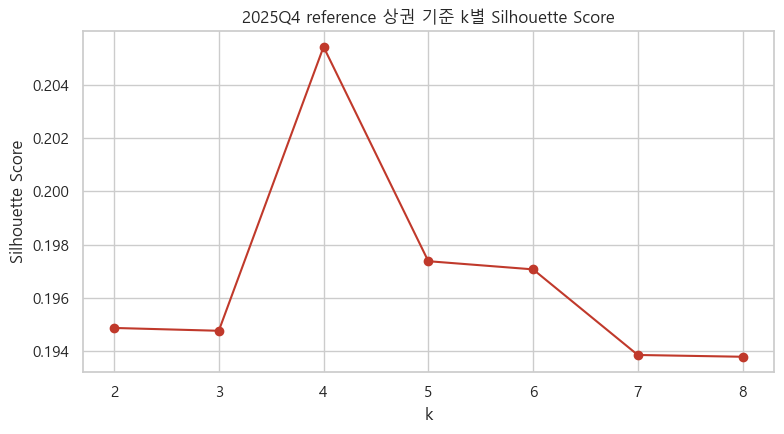

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_scores_df["k"], k_scores_df["silhouette"], marker="o", color=HWANGHAK_COLOR)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} reference 상권 기준 k별 Silhouette Score")
plt.tight_layout()
plt.show()

In [24]:
MIN_CLUSTER_SIZE_RATIO = 0.03  # reference 표본의 3% 미만인 초소형 cluster는 지양
SILHOUETTE_TOLERANCE = 0.01    # 최고 silhouette 대비 이 폭 이내면 사실상 동등하다고 판단

n_reference = len(reference_cluster_df)
k_scores_df["min_size_ok"] = k_scores_df["min_cluster_size"] >= n_reference * MIN_CLUSTER_SIZE_RATIO

best_silhouette = k_scores_df["silhouette"].max()
candidates = k_scores_df[
    (k_scores_df["silhouette"] >= best_silhouette - SILHOUETTE_TOLERANCE) & k_scores_df["min_size_ok"]
]
if len(candidates) > 0:
    FINAL_K = int(candidates["k"].min())
else:
    FINAL_K = int(k_scores_df.loc[k_scores_df["silhouette"].idxmax(), "k"])

print("k별 결과:")
print(k_scores_df.round(3))
print(f"\n최고 silhouette={best_silhouette:.3f} 대비 {SILHOUETTE_TOLERANCE} 이내이면서",
      f"모든 cluster 크기가 reference의 {MIN_CLUSTER_SIZE_RATIO*100:.0f}% 이상인 k 중 가장 작은 k를 선택했다.")
print(f"FINAL_K = {FINAL_K}")

k별 결과:
   k  silhouette  calinski_harabasz  min_cluster_size  max_cluster_size  min_size_ok
0  2       0.195            386.424               689               864         True
1  3       0.195            388.653               490               538         True
2  4       0.205            403.997               314               517         True
3  5       0.197            380.289               243               448         True
4  6       0.197            362.493               185               331         True
5  7       0.194            347.347               165               268         True
6  8       0.194            335.655               123               235         True

최고 silhouette=0.205 대비 0.01 이내이면서 모든 cluster 크기가 reference의 3% 이상인 k 중 가장 작은 k를 선택했다.
FINAL_K = 4


## 20. KMeans 학습

선택한 `FINAL_K`로 reference(서울-황학) 상권에 최종 KMeans를 학습하고, 이 모델로 황학 4개 상권의 cluster를 `predict()`한다.

In [25]:
final_km = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
reference_cluster_df["cluster"] = final_km.fit_predict(X_reference_cluster)
hwanghak_cluster_df["cluster"] = final_km.predict(X_hwanghak_cluster)

latest_cluster_result = pd.concat([reference_cluster_df, hwanghak_cluster_df], ignore_index=False)

print("cluster 크기 분포(reference + 황학):")
print(latest_cluster_result["cluster"].value_counts().sort_index())

C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


cluster 크기 분포(reference + 황학):
cluster
0    394
1    330
2    517
3    316
Name: count, dtype: int64


## 21. cluster profile

cluster 번호 자체는 의미가 없다. 각 cluster의 signal 평균을 확인해 특징을 비교한 뒤에만(섹션 22) 사람이 이해할 수 있는 이름을 부여한다.

`change_intensity_score`는 clustering 입력(`CLUSTER_FEATURE_COLS`)에서는 제외했지만, `structural_change_score`/`decoupling_score`/`instability_score`를 종합한 지표로서 cluster 특징을 요약해서 보여주는 데는 유용하므로 `PROFILE_COLS`에는 별도로 추가한다(clustering에 사용한 4개 입력 + 종합지표 1개 + `anomaly_percentile` 1개).

In [26]:
PROFILE_COLS = CLUSTER_FEATURE_COLS + ["change_intensity_score", "anomaly_percentile"]
assert len(PROFILE_COLS) == len(set(PROFILE_COLS)), "PROFILE_COLS에 중복 컬럼이 있습니다."

cluster_profile = latest_cluster_result.groupby("cluster")[PROFILE_COLS].mean().round(2)
cluster_profile["n_areas"] = latest_cluster_result["cluster"].value_counts().sort_index()
cluster_profile

,direction_score,structural_change_score,decoupling_score,instability_score,change_intensity_score,anomaly_percentile,n_areas
cluster,,,,,,,
0,0.06,58.53,73.79,57.35,63.22,65.12,394
1,0.39,44.52,34.74,58.72,45.99,42.78,330
2,-0.02,35.17,50.28,34.85,40.10,42.30,517
3,-0.44,52.28,35.50,56.23,48.01,51.10,316


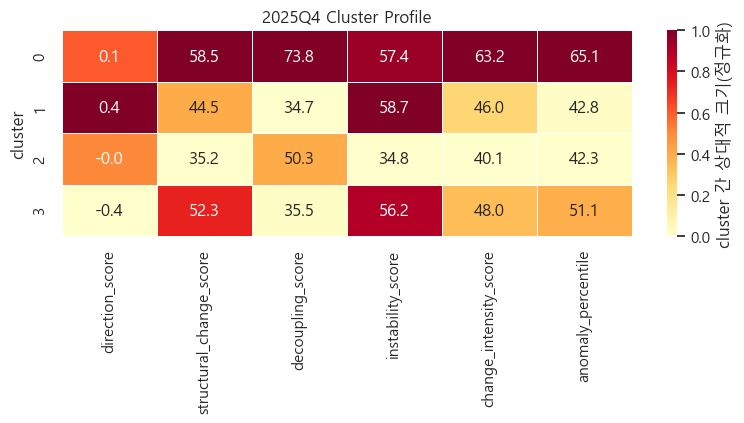

In [27]:
# 필수 시각화: cluster profile heatmap (셀 숫자=실제 평균값, 색상=cluster 간 상대적 크기로 정규화)
profile_display = cluster_profile[PROFILE_COLS]
profile_norm = (profile_display - profile_display.min()) / (profile_display.max() - profile_display.min() + 1e-9)

fig, ax = plt.subplots(figsize=(8, 0.6 * len(cluster_profile) + 2))
sns.heatmap(profile_norm, annot=profile_display.round(1).astype(str), fmt="", cmap="YlOrRd",
            cbar_kws={"label": "cluster 간 상대적 크기(정규화)"}, linewidths=0.5, ax=ax)
ax.set_title(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} Cluster Profile")
plt.tight_layout()
plt.show()

## 22. cluster label

cluster 번호에 이름을 붙이되, **미리 정한 이름에 결과를 끼워 맞추지 않는다.** `direction_score`는 절대적인 기준(중립 구간)으로, `change_intensity_score`는 cluster 간 상대적인 기준(전체 cluster의 중앙값 대비 高/低)으로 판단한다.

`direction_score`를 상대 순위만으로 판단하면 문제가 생길 수 있다. 예를 들어 두 cluster의 `direction_score` 평균이 각각 +0.001, -0.001처럼 사실상 동일하게 0에 가까운데도, 순위만 보면 항상 한쪽은 "증가", 다른 한쪽은 "감소"로 갈리게 된다. 이를 막기 위해 `direction_score`가 `±0.05`(전체 표준편차 대비 충분히 작은 폭) 이내면 방향을 표시하지 않고 변화 강도만으로 이름을 짓고("고변화형"/"저변화형"), 그 범위를 벗어날 때만 "상대적 증가"/"상대적 감소"를 붙인다(예: "상대적 증가·고변화형"). `change_intensity_score`는 애초에 방향이 없는 강도 지표이므로 cluster 간 상대 비교(중앙값 기준 고/저)를 그대로 사용한다.

**중요한 주의사항**: `cluster_label`은 **cluster centroid(profile 평균)를 설명하는 사후적 descriptive label**일 뿐, 그 cluster에 속한 개별 상권의 방향 판정이 아니다. cluster 평균 `direction_score`가 중립 구간 안에 있더라도, 그 cluster에 속한 개별 상권의 `direction_score`는 +0.5나 -0.5처럼 클 수 있다(cluster 내부에서 서로 다른 방향의 상권들이 상쇄되어 평균이 중립으로 보일 수 있기 때문). 따라서 특정 상권을 해석할 때는 반드시 `cluster_label`이 아니라 그 상권 자신의 `direction_score`/`change_intensity_score` 값을 함께 확인해야 한다.

In [28]:
def derive_cluster_labels(profile, direction_neutral_band=0.05):
    """cluster centroid(profile 평균) 기준의 사후적 descriptive label을 만든다.
    direction은 절대 중립구간(±direction_neutral_band)으로, intensity는 cluster 간 상대비교(중앙값)로 판단한다.
    이 label은 cluster 평균을 설명할 뿐 개별 상권의 방향을 의미하지 않는다."""
    intensity_median = profile["change_intensity_score"].median()

    labels = {}
    for cluster_id, row in profile.iterrows():
        direction = row["direction_score"]
        intensity = row["change_intensity_score"]

        if direction > direction_neutral_band:
            direction_tag = "상대적 증가"
        elif direction < -direction_neutral_band:
            direction_tag = "상대적 감소"
        else:
            direction_tag = None

        intensity_tag = "고변화형" if intensity >= intensity_median else "저변화형"

        label = intensity_tag if direction_tag is None else f"{direction_tag}·{intensity_tag}"
        labels[cluster_id] = label
    return labels


cluster_label_map = derive_cluster_labels(cluster_profile)
cluster_profile["cluster_label"] = cluster_profile.index.map(cluster_label_map)
latest_cluster_result["cluster_label"] = latest_cluster_result["cluster"].map(cluster_label_map)

print("cluster_label은 direction_score(중립 구간 ±0.05 기준, 벗어날 때만 상대적 증가/감소 표시)와",
      "change_intensity_score(cluster 간 중앙값 기준 고변화/저변화)를 조합해 사후에 부여한 설명적 이름이며,",
      "cluster centroid를 설명할 뿐 개별 상권의 방향 판정이 아니다.\n")
cluster_profile[["n_areas", "direction_score", "change_intensity_score", "cluster_label"]]

cluster_label은 direction_score(중립 구간 ±0.05 기준, 벗어날 때만 상대적 증가/감소 표시)와 change_intensity_score(cluster 간 중앙값 기준 고변화/저변화)를 조합해 사후에 부여한 설명적 이름이며, cluster centroid를 설명할 뿐 개별 상권의 방향 판정이 아니다.



,n_areas,direction_score,change_intensity_score,cluster_label
cluster,,,,
0,394,0.06,63.22,상대적 증가·고변화형
1,330,0.39,45.99,상대적 증가·저변화형
2,517,-0.02,40.10,저변화형
3,316,-0.44,48.01,상대적 감소·고변화형


## 23. PCA visualization

cluster의 시각적 이해를 돕기 위해 PCA 2차원 투영을 사용한다. PCA는 **시각화 목적**으로만 사용하며, PC1/PC2의 위치 자체에 별도의 경제적 의미를 부여하지 않는다. reference로 PCA를 학습하고 황학을 포함한 전체를 transform한다.

PCA 설명 분산 비율(PC1, PC2): [0.307 0.272]


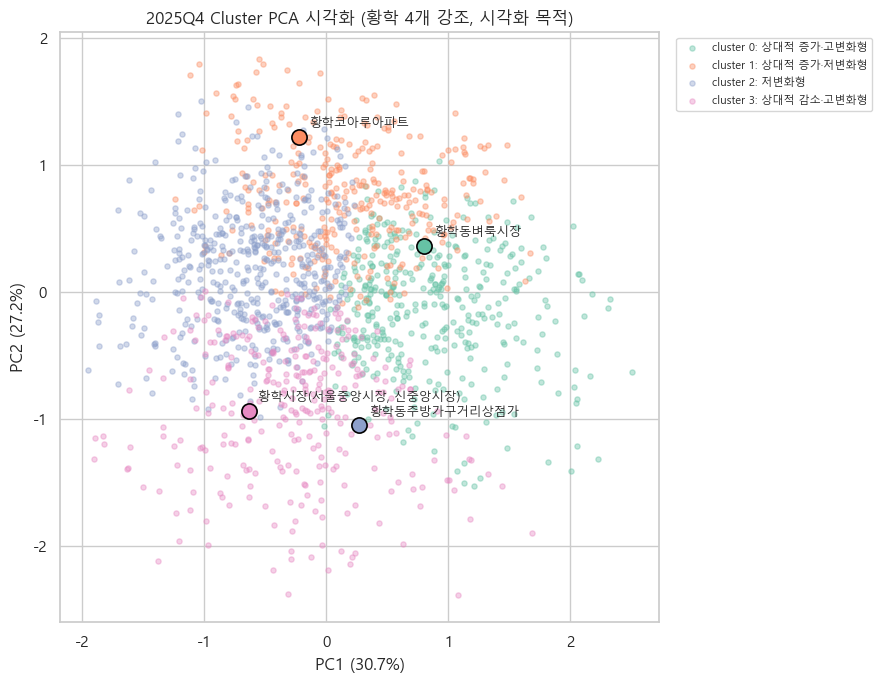

In [29]:
X_all_cluster_scaled = np.vstack([X_reference_cluster, X_hwanghak_cluster])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca.fit(X_reference_cluster)
pcs_all = pca.transform(X_all_cluster_scaled)

pca_plot_df = latest_cluster_result[["상권_코드", "상권_코드_명", "cluster", "cluster_label"]].copy()
pca_plot_df["pc1"] = pcs_all[:, 0]
pca_plot_df["pc2"] = pcs_all[:, 1]

print("PCA 설명 분산 비율(PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("Set2", FINAL_K)
for cluster_id in sorted(pca_plot_df["cluster"].unique()):
    sub = pca_plot_df[(pca_plot_df["cluster"] == cluster_id) & (~pca_plot_df["상권_코드"].isin(HWANGHAK_CODES))]
    ax.scatter(sub["pc1"], sub["pc2"], s=14, alpha=0.4, color=palette[cluster_id],
               label=f"cluster {cluster_id}: {cluster_label_map[cluster_id]}")

hw_pca = pca_plot_df[pca_plot_df["상권_코드"].isin(HWANGHAK_CODES)]
for i, code_ in enumerate(HWANGHAK_CODES):
    row = hw_pca[hw_pca["상권_코드"] == code_]
    if len(row) == 0:
        continue
    ax.scatter(row["pc1"], row["pc2"], s=120, color=AREA_PALETTE[i], edgecolor="black", linewidth=1.2, zorder=5)
    ax.annotate(row["상권_코드_명"].iloc[0], (row["pc1"].iloc[0], row["pc2"].iloc[0]),
                textcoords="offset points", xytext=(7, 7), fontsize=9)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"{QUARTER_LABEL_MAP[LATEST_QUARTER]} Cluster PCA 시각화 (황학 4개 강조, 시각화 목적)")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 24. 황학동 4개 상권 시계열 signal

최신 분기 한 시점만 보면 신호가 언제부터 나타났는지 알 수 없다. `signal_eligible`이 시작되는 2022Q1부터 최신 분기까지 황학 4개 상권의 `direction_score`, `change_intensity_score`, `anomaly_percentile` 추이를 각각 하나의 그래프에 4개 상권을 겹쳐 그린다(무리하게 한 그래프에 모든 지표를 넣지 않는다).

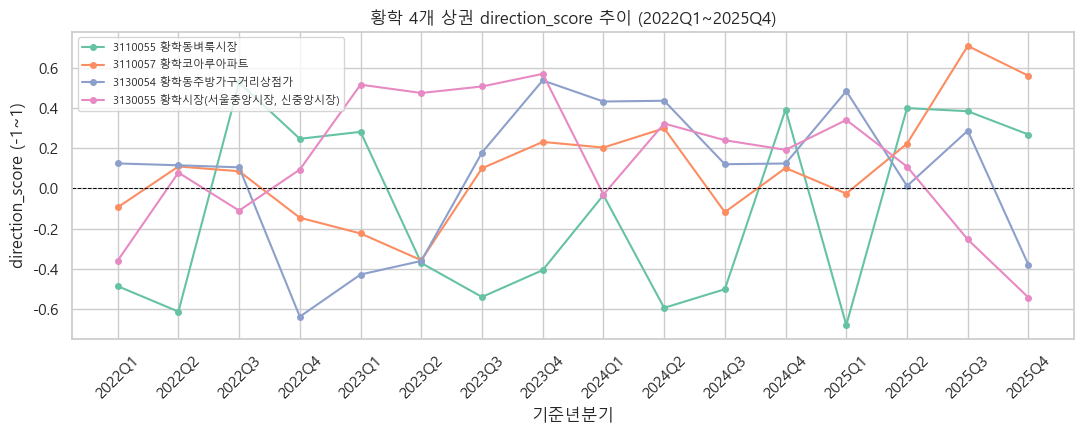

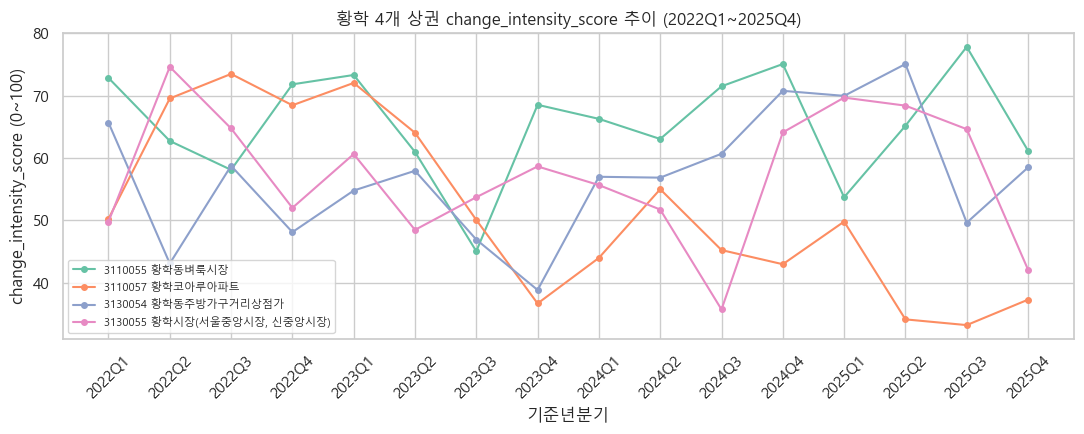

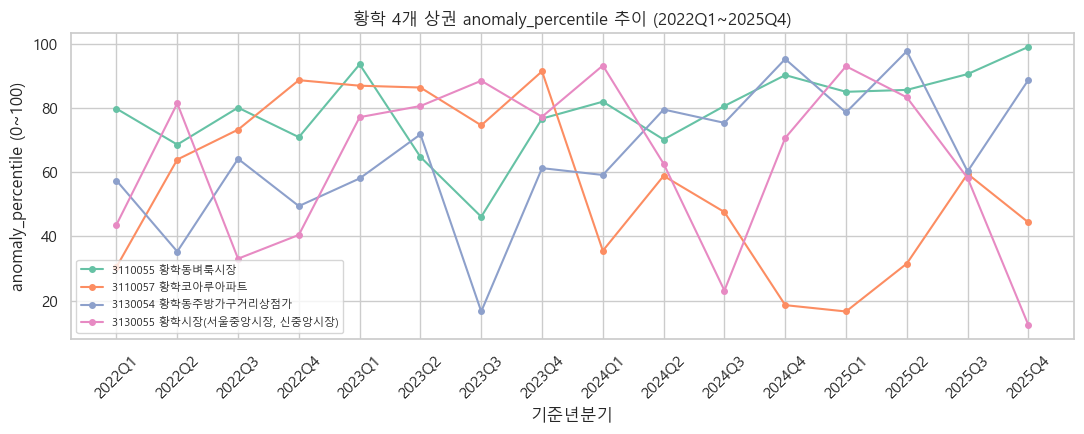

In [30]:
hwanghak_signals = signals[
    signals["상권_코드"].isin(HWANGHAK_CODES) & (signals["기준_년분기_코드"] >= ANALYSIS_START_QUARTER)
].copy()
hwanghak_signals = hwanghak_signals.sort_values(["상권_코드", "기준_년분기_코드"])

TS_METRICS = [
    ("direction_score", "direction_score (-1~1)"),
    ("change_intensity_score", "change_intensity_score (0~100)"),
    ("anomaly_percentile", "anomaly_percentile (0~100)"),
]

for metric, ylabel in TS_METRICS:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for i, code_ in enumerate(HWANGHAK_CODES):
        sub = hwanghak_signals[hwanghak_signals["상권_코드"] == code_]
        ax.plot(sub["분기_라벨"], sub[metric], marker="o", markersize=4, color=AREA_PALETTE[i],
                label=f"{code_} {sub['상권_코드_명'].iloc[0]}")
    if metric == "direction_score":
        ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_xlabel("기준년분기")
    ax.set_ylabel(ylabel)
    ax.set_title(f"황학 4개 상권 {metric} 추이 ({QUARTER_LABEL_MAP[ANALYSIS_START_QUARTER]}~{QUARTER_LABEL_MAP[LATEST_QUARTER]})")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 25. 최신 분기 황학동 종합 진단표

최신 분기 기준으로 황학 4개 상권의 핵심 signal을 하나의 표로 정리한다. percentile만 보면 실제 증가/감소 여부를 알기 어렵기 때문에, 원본 raw YoY(%)와 동일 분기 percentile을 함께 배치해 "실제 변화율"과 "서울 내 상대적 위치"를 동시에 확인할 수 있게 한다. 실제 계산 가능 여부를 확인해 존재하지 않는 컬럼은 억지로 만들지 않는다.

In [31]:
SUMMARY_COLS_WANTED = [
    "상권_코드", "상권_코드_명",
    "direction_score", "direction_percentile",
    "structural_change_score", "decoupling_score", "instability_score", "change_intensity_score",
    "anomaly_score", "anomaly_percentile", "attention_flag",
    "cluster", "cluster_label",
    "sales_percentile", "store_percentile", "population_percentile",
    "sales_yoy", "sales_yoy_percentile",
    "transactions_yoy", "transactions_yoy_percentile",
    "stores_yoy", "stores_yoy_percentile",
    "population_yoy", "population_yoy_percentile",
    "sales_population_yoy_percentile_gap", "sales_store_yoy_percentile_gap",
    "sales_population_percentile_gap", "sales_store_percentile_gap",
]

latest_full = signals[signals["기준_년분기_코드"] == LATEST_QUARTER].merge(
    latest_cluster_result[["상권_코드", "cluster", "cluster_label"]], on="상권_코드", how="left"
)

available_summary_cols = [c for c in SUMMARY_COLS_WANTED if c in latest_full.columns]
missing_summary_cols = [c for c in SUMMARY_COLS_WANTED if c not in latest_full.columns]
print("사용 가능한 진단표 컬럼 수:", len(available_summary_cols), "/", len(SUMMARY_COLS_WANTED))
if missing_summary_cols:
    print("실제 데이터에 존재하지 않아 제외한 컬럼:", missing_summary_cols)

hwanghak_summary = latest_full[latest_full["상권_코드"].isin(HWANGHAK_CODES)][available_summary_cols].set_index("상권_코드")
hwanghak_summary.round(2)

사용 가능한 진단표 컬럼 수: 28 / 28


,상권_코드_명,direction_score,direction_percentile,structural_change_score,decoupling_score,instability_score,change_intensity_score,anomaly_score,anomaly_percentile,attention_flag,cluster,cluster_label,sales_percentile,store_percentile,population_percentile,sales_yoy,sales_yoy_percentile,transactions_yoy,transactions_yoy_percentile,stores_yoy,stores_yoy_percentile,population_yoy,population_yoy_percentile,sales_population_yoy_percentile_gap,sales_store_yoy_percentile_gap,sales_population_percentile_gap,sales_store_percentile_gap
상권_코드,,,,,,,,,,,,,,,,,,,,,,,,,,,
3110055,황학동벼룩시장,0.27,76.81,54.39,79.63,49.51,61.18,0.60,99.10,True,0.0,상대적 증가·고변화형,37.64,35.64,35.86,74.34,96.86,17.02,88.01,-1.06,66.48,-30.18,2.25,94.61,30.37,1.77,2.00
3110057,황학코아루아파트,0.56,94.61,37.25,20.85,53.65,37.25,0.49,44.37,False,1.0,상대적 증가·저변화형,47.28,38.24,66.99,12.87,80.05,19.38,89.29,-0.98,67.33,3.49,75.30,4.75,12.72,-19.71,9.04
3130054,황학동주방가구거리상점가,-0.38,14.19,70.89,55.21,49.36,58.48,0.55,88.81,False,3.0,상대적 감소·고변화형,51.57,64.67,75.18,-14.23,16.16,-24.71,9.56,2.58,89.52,-18.05,8.86,7.30,-73.35,-23.62,-13.10
3130055,"황학시장(서울중앙시장, 신중앙시장)",-0.54,6.87,39.91,31.59,54.75,42.08,0.46,12.35,False,3.0,상대적 감소·고변화형,53.55,60.97,67.23,-18.10,13.02,-15.16,19.37,-2.73,46.12,-14.13,13.17,-0.15,-33.10,-13.69,-7.42


## 26. 황학동 domain-informed feature 추가 해석

AI 결과가 나온 뒤, 황학동을 해석하는 이 마지막 단계에서만 `03_eda.ipynb` 기반 domain-informed feature(`furniture_sales_share`, `korean_food_sales_share`, `ecommerce_sales_share`)와 구조 관련 feature(`weekend_sales_share`, `evening_night_sales_share`, `industry_hhi`)를 함께 살펴본다. anomaly_percentile이 높아진 시점과 이 feature들의 변화가 함께 나타나는지 확인하되, 인과관계는 주장하지 않는다.

**단위 주의**: `*_share` feature는 0~1 비율이므로 변화량에 percentage point(%p)를 붙이려면 `x 100`을 곱해야 한다(예: 0.798의 변화는 `+0.798%p`가 아니라 `+79.8%p`). 반면 `industry_hhi`는 비율(share)이 아니라 제곱합 지수이므로 `%p` 단위를 붙이지 않고 지수 값 자체의 변화로 표시한다. 두 종류를 하나의 `%p` 표에 섞지 않는다.

In [32]:
DOMAIN_SHARE_COLS = [
    "furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share",
    "weekend_sales_share", "evening_night_sales_share",
]
DOMAIN_HHI_COL = "industry_hhi"
DOMAIN_INFORMED_COLS = DOMAIN_SHARE_COLS + [DOMAIN_HHI_COL]

hwanghak_domain_latest = features[
    (features["기준_년분기_코드"] == LATEST_QUARTER) & (features["상권_코드"].isin(HWANGHAK_CODES))
][["상권_코드", "상권_코드_명"] + DOMAIN_INFORMED_COLS].set_index("상권_코드")

print(f"[{QUARTER_LABEL_MAP[LATEST_QUARTER]} 황학 4개 상권 domain-informed feature (원본 비율/지수 값)]")
display(hwanghak_domain_latest.round(3))

hwanghak_domain_first = features[
    (features["기준_년분기_코드"] == ANALYSIS_START_QUARTER) & (features["상권_코드"].isin(HWANGHAK_CODES))
][["상권_코드"] + DOMAIN_INFORMED_COLS].set_index("상권_코드")

share_change_pp = (hwanghak_domain_latest[DOMAIN_SHARE_COLS] - hwanghak_domain_first[DOMAIN_SHARE_COLS]) * 100
print(f"\n[{QUARTER_LABEL_MAP[ANALYSIS_START_QUARTER]} -> {QUARTER_LABEL_MAP[LATEST_QUARTER]}",
      "share 변화 (percentage point, %p)]")
display(share_change_pp.round(2))

print(f"\n[{QUARTER_LABEL_MAP[ANALYSIS_START_QUARTER]} -> {QUARTER_LABEL_MAP[LATEST_QUARTER]} industry_hhi 변화 (지수 값 차이, %p 아님)]")
for area_code in HWANGHAK_CODES:
    name_ = hwanghak_domain_latest.loc[area_code, "상권_코드_명"]
    first_hhi = hwanghak_domain_first.loc[area_code, DOMAIN_HHI_COL]
    latest_hhi = hwanghak_domain_latest.loc[area_code, DOMAIN_HHI_COL]
    print(f" - {area_code} {name_}: industry_hhi {first_hhi:.3f} -> {latest_hhi:.3f}, 변화 {latest_hhi - first_hhi:+.3f}")

print("\n[참고] 위 anomaly/direction/change_intensity 결과와 이 domain-informed feature 변화가 동시에 나타나는지는",
      "섹션 17의 feature deviation 결과와 함께 정성적으로만 참고하며, 이 노트북에서 통계적 인과관계를 검정하지 않는다.")

[2025Q4 황학 4개 상권 domain-informed feature (원본 비율/지수 값)]


,상권_코드_명,furniture_sales_share,korean_food_sales_share,ecommerce_sales_share,weekend_sales_share,evening_night_sales_share,industry_hhi
상권_코드,,,,,,,
3110055,황학동벼룩시장,0.000,0.116,0.798,0.818,0.073,0.654
3110057,황학코아루아파트,0.000,0.599,0.000,0.289,0.549,0.400
3130054,황학동주방가구거리상점가,0.569,0.086,0.000,0.203,0.213,0.359
3130055,"황학시장(서울중앙시장, 신중앙시장)",0.009,0.322,0.000,0.235,0.410,0.216



[2022Q1 -> 2025Q4 share 변화 (percentage point, %p)]


,furniture_sales_share,korean_food_sales_share,ecommerce_sales_share,weekend_sales_share,evening_night_sales_share
상권_코드,,,,,
3110055,0.00,-45.89,79.79,53.26,-19.81
3110057,0.00,19.97,0.00,5.37,9.18
3130054,-0.91,-3.38,0.00,6.66,7.97
3130055,-2.29,3.26,0.00,-3.78,4.32



[2022Q1 -> 2025Q4 industry_hhi 변화 (지수 값 차이, %p 아님)]
 - 3110055 황학동벼룩시장: industry_hhi 0.394 -> 0.654, 변화 +0.260
 - 3110057 황학코아루아파트: industry_hhi 0.295 -> 0.400, 변화 +0.106
 - 3130054 황학동주방가구거리상점가: industry_hhi 0.372 -> 0.359, 변화 -0.013
 - 3130055 황학시장(서울중앙시장, 신중앙시장): industry_hhi 0.262 -> 0.216, 변화 -0.046

[참고] 위 anomaly/direction/change_intensity 결과와 이 domain-informed feature 변화가 동시에 나타나는지는 섹션 17의 feature deviation 결과와 함께 정성적으로만 참고하며, 이 노트북에서 통계적 인과관계를 검정하지 않는다.


### `ecommerce_sales_share` 등 share 변수 sanity check

황학동벼룩시장에서 `ecommerce_sales_share`(전자상거래업 매출 비중)가 상당히 높게 나타날 수 있다. 값이 크다는 이유만으로 오류라고 단정하거나 임의로 수정하지 않고, 계산 정의와 실제 값 분포를 확인해 정상적으로 계산된 값인지 점검한다.

In [33]:
# (1) 04_feature_engineering.ipynb / feature_dictionary.csv에서 정의 재확인
_share_dict_rows = feature_dictionary[feature_dictionary["feature"].isin(DOMAIN_SHARE_COLS)]
print("[feature_dictionary.csv에 기록된 정의]")
display(_share_dict_rows[["feature", "definition", "caution"]])

# (2) share 변수는 원칙적으로 0~1 범위여야 한다 - 위반 사례가 있으면 개수와 샘플을 먼저 확인한다
for col in DOMAIN_SHARE_COLS:
    valid = features[col].dropna()
    out_of_range = features[(features[col] < 0) | (features[col] > 1)]
    print(f"\n{col}: 관측치 {len(valid)}건, 범위 [{valid.min():.4f}, {valid.max():.4f}], "
          f"0~1 범위를 벗어난 행 {len(out_of_range)}건")
    if len(out_of_range) > 0:
        display(out_of_range[["기준_년분기_코드", "상권_코드", "상권_코드_명", col]].head(5))

# (3) 황학 4개 상권의 최신 값 (위 표에 이미 표시됨) + 서울 전체 상위 값 비교
print(f"\n[{QUARTER_LABEL_MAP[LATEST_QUARTER]} 서울 전체 ecommerce_sales_share 상위 10개 상권]")
_ecommerce_top = features[features["기준_년분기_코드"] == LATEST_QUARTER].nlargest(10, "ecommerce_sales_share")
display(_ecommerce_top[["상권_코드", "상권_코드_명", "ecommerce_sales_share", "total_sales"]])

print("\n[해석 범위] 위에서 확인한 것: (1) feature_dictionary.csv에 기록된 계산 정의, (2) 0~1 이론적 범위 위반 여부,",
      "(3) 황학동 4개 상권의 최신 값, (4) 서울 전체 분포에서의 상대적 위치. 이 범위 안에서는",
      "기계적인 계산 또는 범위 오류의 명확한 징후가 발견되지 않았다.")
print("[검증하지 않은 것] 원천 데이터의 서비스_업종_코드 분류 자체가 실제 업종을 정확히 반영하는지는",
      "이 노트북에서 검증하지 않았다. 따라서 값이 높다는 것은 '해당 분기 그 상권 매출이 특정 업종(전자상거래업)에",
      "크게 집중되어 있다'는 관측 사실로만 해석하며, 계산 구조상 발견되지 않은 오류의 부재가",
      "원천 업종 분류의 정확성까지 보장하지는 않는다. 이 범위를 벗어난 근거 없이 값을 임의로 수정하지 않는다.")

[feature_dictionary.csv에 기록된 정의]


,feature,definition,caution
17,weekend_sales_share,주말_매출_금액 / (주중_매출_금액 + 주말_매출_금액),분모 0이면 NaN
21,evening_night_sales_share,(17~21시+21~24시) 매출 / 6개 시간대 매출 합,분모 0이면 NaN
38,furniture_sales_share,'가구' 업종 매출 / 상권x분기 전체 매출,"서울 전체 통계로 자동 선정된 업종이 아니며, 실제 서비스_업종_코드_명 '가구' ..."
39,korean_food_sales_share,'한식음식점' 업종 매출 / 상권x분기 전체 매출,"서울 전체 통계로 자동 선정된 업종이 아니며, 실제 서비스_업종_코드_명 '한식음식..."
40,ecommerce_sales_share,'전자상거래업' 업종 매출 / 상권x분기 전체 매출,"서울 전체 통계로 자동 선정된 업종이 아니며, 실제 서비스_업종_코드_명 '전자상거..."



furniture_sales_share: 관측치 31415건, 범위 [0.0000, 1.0000], 0~1 범위를 벗어난 행 0건

korean_food_sales_share: 관측치 31415건, 범위 [0.0000, 1.0000], 0~1 범위를 벗어난 행 0건

ecommerce_sales_share: 관측치 31415건, 범위 [0.0000, 1.0000], 0~1 범위를 벗어난 행 0건

weekend_sales_share: 관측치 31415건, 범위 [0.0000, 1.0000], 0~1 범위를 벗어난 행 0건

evening_night_sales_share: 관측치 31415건, 범위 [0.0000, 1.0000], 0~1 범위를 벗어난 행 0건

[2025Q4 서울 전체 ecommerce_sales_share 상위 10개 상권]


,상권_코드,상권_코드_명,ecommerce_sales_share,total_sales
2179,3110103,옥수터널,1.000000,3.000000e+06
32139,3130280,신림종합시장,1.000000,1.000000e+07
1219,3110055,황학동벼룩시장,0.797896,1.897329e+09
19599,3110974,언주중학교,0.643460,3.395069e+08
2199,3110104,신금호역 4번,0.316179,1.345075e+09
11419,3110565,홍익대,0.280472,1.187285e+09
1479,3110068,남영역 1번,0.235728,1.086420e+10
18959,3110942,염곡동 구룡사(포이동성당),0.175163,1.128533e+10
16579,3110823,신대방삼거리역 3번,0.161325,7.429420e+08
11079,3110548,마포구청역 4번,0.140523,2.505173e+09



[해석 범위] 위에서 확인한 것: (1) feature_dictionary.csv에 기록된 계산 정의, (2) 0~1 이론적 범위 위반 여부, (3) 황학동 4개 상권의 최신 값, (4) 서울 전체 분포에서의 상대적 위치. 이 범위 안에서는 기계적인 계산 또는 범위 오류의 명확한 징후가 발견되지 않았다.
[검증하지 않은 것] 원천 데이터의 서비스_업종_코드 분류 자체가 실제 업종을 정확히 반영하는지는 이 노트북에서 검증하지 않았다. 따라서 값이 높다는 것은 '해당 분기 그 상권 매출이 특정 업종(전자상거래업)에 크게 집중되어 있다'는 관측 사실로만 해석하며, 계산 구조상 발견되지 않은 오류의 부재가 원천 업종 분류의 정확성까지 보장하지는 않는다. 이 범위를 벗어난 근거 없이 값을 임의로 수정하지 않는다.


## 27. output 저장

`data/processed/commercial_features.csv`/`feature_dictionary.csv`는 절대 덮어쓰지 않는다. 이번 노트북의 결과는 다음 3개 파일로 새로 저장한다.

- `commercial_signals.csv`: `기준_년분기_코드 x 상권_코드` grain(33,000행)을 그대로 유지한 전체 signal 테이블
- `latest_commercial_typology.csv`: 최신 분기 상권별 signal score + anomaly + cluster
- `signal_dictionary.csv`: 이번 노트북에서 새로 만든 signal에 대한 정의/해석/주의사항
- `hwanghak_anomaly_drivers.csv`: 황학 4개 상권 x `LATEST_QUARTER` 기준 Anomaly Driver(Top 3 abnormal input feature, 섹션 17) — Isolation Forest의 feature importance가 아니라 입력 feature의 서울 분포 내 percentile 기반 이상성 요약이며, `07_strategy_recommendation.ipynb`에서 그대로 불러와 최종 결과에 연결한다.

In [34]:
SIGNAL_IDENTIFIER_COLS = ["기준_년분기_코드", "분기_라벨", "상권_코드", "상권_코드_명", "상권_구분_코드", "상권_구분_코드_명"]
SIGNAL_COVERAGE_COLS = ["has_sales", "has_stores", "has_population", "complete_case", "signal_eligible", "if_input_complete"]

SIGNAL_TRANSFORM_COLS = (
    ["transactions_yoy_percentile"]
    + [name for _, name in STRUCTURAL_CHANGE_COMPONENTS]
    + structural_percentile_cols
    + decoupling_signed_gap_cols
    + decoupling_abs_gap_cols
    + decoupling_abs_percentile_cols
    + instability_percentile_cols
)
SIGNAL_SCORE_COLS = [
    "direction_score", "direction_percentile",
    "structural_change_score", "decoupling_score", "instability_score", "change_intensity_score",
]
SIGNAL_AI_COLS = ["anomaly_score", "anomaly_percentile", "attention_flag"]
# sales_population_percentile_gap / sales_store_percentile_gap은 04에서 만들어진 "레벨(규모)" percentile gap으로,
# decoupling_score의 구성요소(YoY 기반)와는 다른 의미다. 혼동 방지를 위해 이 노트북의 SIGNAL_TRANSFORM_COLS에는
# 포함하지 않고, 04 feature_dictionary.csv에 이미 정의된 context feature로만 별도 보존한다.
SIGNAL_CONTEXT_COLS = (
    CONTEXT_PERCENTILE_COLS + RAW_YOY_COLS
    + ["sales_population_percentile_gap", "sales_store_percentile_gap"]
)

SIGNAL_COLUMN_ORDER = (
    SIGNAL_IDENTIFIER_COLS + SIGNAL_COVERAGE_COLS + SIGNAL_TRANSFORM_COLS
    + SIGNAL_SCORE_COLS + SIGNAL_AI_COLS + SIGNAL_CONTEXT_COLS
)

missing_in_signals = set(SIGNAL_COLUMN_ORDER) - set(signals.columns)
assert not missing_in_signals, f"commercial_signals에 포함하려는 컬럼이 signals에 없습니다: {missing_in_signals}"
assert len(SIGNAL_COLUMN_ORDER) == len(set(SIGNAL_COLUMN_ORDER)), "SIGNAL_COLUMN_ORDER에 중복 컬럼이 있습니다."

commercial_signals = signals[SIGNAL_COLUMN_ORDER].copy()
print("commercial_signals shape:", commercial_signals.shape)
commercial_signals.head(3)

commercial_signals shape: (33000, 55)


,기준_년분기_코드,분기_라벨,상권_코드,상권_코드_명,상권_구분_코드,상권_구분_코드_명,has_sales,has_stores,has_population,complete_case,signal_eligible,if_input_complete,transactions_yoy_percentile,weekend_share_yoy_change,evening_share_yoy_change,industry_hhi_yoy_change,top1_share_yoy_change,active_industry_yoy_change,weekend_share_yoy_change_abs_percentile,evening_share_yoy_change_abs_percentile,industry_hhi_yoy_change_abs_percentile,top1_share_yoy_change_abs_percentile,active_industry_yoy_change_abs_percentile,sales_population_yoy_percentile_gap,sales_store_yoy_percentile_gap,sales_population_yoy_gap_abs,sales_store_yoy_gap_abs,sales_population_yoy_gap_abs_percentile,sales_store_yoy_gap_abs_percentile,sales_4q_cv_percentile,closing_intensity_percentile,opening_intensity_percentile,direction_score,direction_percentile,structural_change_score,decoupling_score,instability_score,change_intensity_score,anomaly_score,anomaly_percentile,attention_flag,sales_percentile,store_percentile,population_percentile,sales_yoy_percentile,population_yoy_percentile,stores_yoy_percentile,weekend_share_percentile,evening_share_percentile,sales_yoy,transactions_yoy,stores_yoy,population_yoy,sales_population_percentile_gap,sales_store_percentile_gap
0,20211,2021Q1,3001491,이태원 관광특구,U,관광특구,True,True,True,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.303030,31.515152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,96.696315,97.212121,88.060606,NaN,NaN,NaN,95.743329,70.203304,NaN,NaN,NaN,NaN,8.635709,-0.515806
1,20212,2021Q2,3001491,이태원 관광특구,U,관광특구,True,True,True,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.636364,54.363636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,97.202797,97.151515,90.303030,NaN,NaN,NaN,94.342022,72.981564,NaN,NaN,NaN,NaN,6.899767,0.051282
2,20213,2021Q3,3001491,이태원 관광특구,U,관광특구,True,True,True,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.939394,51.515152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,96.562699,97.151515,89.333333,NaN,NaN,NaN,95.289624,71.928708,NaN,NaN,NaN,NaN,7.229366,-0.588816


In [35]:
typology_cols = (
    ["기준_년분기_코드", "분기_라벨", "상권_코드", "상권_코드_명", "상권_구분_코드", "상권_구분_코드_명"]
    + SIGNAL_SCORE_COLS + SIGNAL_AI_COLS + ["cluster", "cluster_label"]
)
typology_cols = [c for c in typology_cols if c in latest_full.columns]

latest_typology = latest_full[typology_cols].copy()
print("latest_commercial_typology shape:", latest_typology.shape)
latest_typology.head(3)

latest_commercial_typology shape: (1650, 17)


,기준_년분기_코드,분기_라벨,상권_코드,상권_코드_명,상권_구분_코드,상권_구분_코드_명,direction_score,direction_percentile,structural_change_score,decoupling_score,instability_score,change_intensity_score,anomaly_score,anomaly_percentile,attention_flag,cluster,cluster_label
0,20254,2025Q4,3001491,이태원 관광특구,U,관광특구,0.131042,64.354528,30.878768,47.625015,50.466589,42.990124,0.433206,0.578778,False,2.0,저변화형
1,20254,2025Q4,3001492,명동 남대문 북창동 다동 무교동 관광특구,U,관광특구,0.274545,77.328195,32.225786,36.659000,41.148796,36.677860,0.446587,3.858521,False,2.0,저변화형
2,20254,2025Q4,3001493,동대문패션타운 관광특구,U,관광특구,0.102435,60.822094,67.838358,87.736610,45.413364,66.996111,0.524512,74.405145,False,0.0,상대적 증가·고변화형


In [36]:
SIGNAL_DICTIONARY_ROWS = [
    dict(signal="signal_eligible", category="커버리지",
         definition="기준_년분기_코드>=2022Q1이며 complete_case(has_sales/has_stores/has_population 모두 True)인 행",
         interpretation="이 노트북의 signal/AI 계산에 사용 가능한 관측치인지 여부",
         caution="False인 행은 원본 데이터가 없거나(coverage) 2021년(YoY 구조적 결측)에 해당하며, 점수는 0이 아니라 NaN으로 유지된다"),
    dict(signal="if_input_complete", category="커버리지",
         definition=f"Isolation Forest 입력 feature(AI_FEATURE_COLS, {len(AI_FEATURE_COLS)}개)가 모두 결측 없이 존재하는지 여부",
         interpretation="해당 행이 그 분기 Isolation Forest 학습/평가에 실제로 사용되었는지 여부",
         caution="signal_eligible=True이어도 개별 component 결측으로 False가 될 수 있다"),
    dict(signal="transactions_yoy_percentile", category="signal transformation",
         definition="transactions_yoy의 분기별 서울 전체 상권 percentile(0~100)",
         interpretation="같은 분기 서울 다른 상권과 비교한 거래건수 성장률의 상대적 위치",
         caution="04의 원본 feature가 아니라 05에서 추가한 signal transformation"),
    dict(signal="weekend_share_yoy_change", category="signal transformation",
         definition="weekend_sales_share - 4분기 전 값 (groupby 상권_코드, shift(4))",
         interpretation="주말 매출 비중(0~1 scale)의 전년동기 대비 비율값 차이(부호 있음, ×100 시 percentage point)",
         caution="저장된 값 자체는 0~1 scale의 차이이며 %p 단위가 아니다(예: 0.20이면 20%p에 해당)."
                 " 크기(절대값)는 weekend_share_yoy_change_abs_percentile 참고"),
    dict(signal="evening_share_yoy_change", category="signal transformation",
         definition="evening_night_sales_share - 4분기 전 값",
         interpretation="저녁·야간 매출 비중(0~1 scale)의 전년동기 대비 비율값 차이(부호 있음, ×100 시 percentage point)",
         caution="위와 동일(저장 값은 %p가 아니라 0~1 scale의 비율값 차이)"),
    dict(signal="industry_hhi_yoy_change", category="signal transformation",
         definition="industry_hhi - 4분기 전 값",
         interpretation="업종 집중도(HHI, 비율이 아닌 제곱합 지수)의 전년동기 대비 지수 값 차이(부호 있음)",
         caution="비율(share)이 아니라 지수이므로 %p 단위를 붙이지 않는다"),
    dict(signal="top1_share_yoy_change", category="signal transformation",
         definition="top1_industry_share - 4분기 전 값",
         interpretation="1위 업종 매출 비중(0~1 scale)의 전년동기 대비 비율값 차이(부호 있음, ×100 시 percentage point)",
         caution="저장된 값 자체는 0~1 scale의 차이이며 %p 단위가 아니다"),
    dict(signal="active_industry_yoy_change", category="signal transformation",
         definition="active_industry_count - 4분기 전 값",
         interpretation="매출이 발생한 업종 수의 전년동기 대비 변화(개, 부호 있음)", caution="비율이나 %p가 아닌 업종 수의 절대 개수 변화"),
    dict(signal="weekend_share_yoy_change_abs_percentile", category="signal transformation",
         definition="|weekend_share_yoy_change|의 분기별 서울 전체 percentile",
         interpretation="주말 소비 구조 변화 강도의 상대적 위치", caution="structural_change_score의 구성 요소"),
    dict(signal="evening_share_yoy_change_abs_percentile", category="signal transformation",
         definition="|evening_share_yoy_change|의 분기별 서울 전체 percentile",
         interpretation="저녁·야간 소비 구조 변화 강도의 상대적 위치", caution="structural_change_score의 구성 요소"),
    dict(signal="industry_hhi_yoy_change_abs_percentile", category="signal transformation",
         definition="|industry_hhi_yoy_change|의 분기별 서울 전체 percentile",
         interpretation="업종 집중도 변화 강도의 상대적 위치", caution="structural_change_score의 구성 요소"),
    dict(signal="top1_share_yoy_change_abs_percentile", category="signal transformation",
         definition="|top1_share_yoy_change|의 분기별 서울 전체 percentile",
         interpretation="1위 업종 쏠림 변화 강도의 상대적 위치", caution="structural_change_score의 구성 요소"),
    dict(signal="active_industry_yoy_change_abs_percentile", category="signal transformation",
         definition="|active_industry_yoy_change|의 분기별 서울 전체 percentile",
         interpretation="업종 다양성 변화 강도의 상대적 위치", caution="structural_change_score의 구성 요소"),
    dict(signal="sales_population_yoy_percentile_gap", category="signal transformation",
         definition="sales_yoy_percentile - population_yoy_percentile (둘 다 YoY 변화율의 동일분기 percentile)",
         interpretation="매출 변화와 유동인구 변화의 서울 내 상대적 위치 차이(부호 있음)",
         caution="04의 sales_population_percentile_gap(레벨/규모 gap)과는 다른 개념이다. 이 gap은 '변화'의 엇갈림을 나타낸다"),
    dict(signal="sales_store_yoy_percentile_gap", category="signal transformation",
         definition="sales_yoy_percentile - stores_yoy_percentile (둘 다 YoY 변화율의 동일분기 percentile)",
         interpretation="매출 변화와 점포수 변화의 서울 내 상대적 위치 차이(부호 있음)",
         caution="04의 sales_store_percentile_gap(레벨/규모 gap)과는 다른 개념이다. 이 gap은 '변화'의 엇갈림을 나타낸다"),
    dict(signal="sales_population_yoy_gap_abs", category="signal transformation",
         definition="|sales_population_yoy_percentile_gap|",
         interpretation="매출 변화-유동인구 변화 상대적 위치 괴리의 크기(방향 무관)", caution="decoupling_score의 구성 요소"),
    dict(signal="sales_store_yoy_gap_abs", category="signal transformation",
         definition="|sales_store_yoy_percentile_gap|",
         interpretation="매출 변화-점포수 변화 상대적 위치 괴리의 크기(방향 무관)", caution="decoupling_score의 구성 요소"),
    dict(signal="sales_population_yoy_gap_abs_percentile", category="signal transformation",
         definition="sales_population_yoy_gap_abs의 분기별 서울 전체 percentile",
         interpretation="매출-유동인구 변화 괴리 크기의 상대적 위치", caution="decoupling_score의 구성 요소"),
    dict(signal="sales_store_yoy_gap_abs_percentile", category="signal transformation",
         definition="sales_store_yoy_gap_abs의 분기별 서울 전체 percentile",
         interpretation="매출-점포수 변화 괴리 크기의 상대적 위치", caution="decoupling_score의 구성 요소"),
    dict(signal="sales_4q_cv_percentile", category="signal transformation",
         definition="sales_4q_cv의 분기별 서울 전체 percentile",
         interpretation="최근 4분기 매출 변동성의 상대적 위치",
         caution="instability_score의 구성 요소. 높다고 반드시 쇠퇴를 의미하지 않는다"),
    dict(signal="closing_intensity_percentile", category="signal transformation",
         definition="closing_intensity의 분기별 서울 전체 percentile",
         interpretation="폐업 강도의 상대적 위치", caution="instability_score의 구성 요소"),
    dict(signal="opening_intensity_percentile", category="signal transformation",
         definition="opening_intensity의 분기별 서울 전체 percentile",
         interpretation="개업 강도의 상대적 위치", caution="instability_score의 구성 요소"),
    dict(signal="direction_score", category="Signal Layer 1 (Momentum)",
         definition="sales_yoy_percentile, transactions_yoy_percentile, stores_yoy_percentile, population_yoy_percentile를"
                     " -1~1로 중심화한 뒤 동일가중 평균(최소 3개 이상 존재해야 계산)",
         interpretation="같은 분기 서울 상권 대비 상대적 방향성. -1에 가까울수록 서울 대비 상대적으로 낮은(감소) 방향,"
                         " +1에 가까울수록 서울 대비 상대적으로 높은(증가) 방향",
         caution="쇠퇴/성장의 확정 판정이 아니라 서울 내 상대적 방향성 지표. 구성요소가 모두 percentile이므로"
                 " direction_score>0이라고 해서 실제 YoY가 반드시 양수인 것은 아니다"
                 "(서울 전체가 감소한 분기에는 덜 감소한 상권도 +로 나타날 수 있다)"),
    dict(signal="direction_percentile", category="Signal Layer 1 (Momentum)",
         definition="direction_score의 분기별 서울 전체 percentile",
         interpretation="direction_score 기준 서울 상권 내 상대적 순위", caution="direction_score와 함께 참고"),
    dict(signal="structural_change_score", category="Signal Layer 2 (Structural Change)",
         definition="주말/저녁야간 비중, 업종 HHI, top1 비중, 활성 업종 수의 |YoY change| percentile 평균"
                     "(0~100, 최소 3개 이상 존재해야 계산)",
         interpretation="상권의 소비/업종 구조가 서울 다른 상권 대비 얼마나 크게 변하고 있는지의 강도",
         caution="방향(좋음/나쁨)이 아니라 변화의 크기(강도)를 나타낸다"),
    dict(signal="decoupling_score", category="Signal Layer 3 (Decoupling)",
         definition="sales_yoy_percentile과 population_yoy_percentile/stores_yoy_percentile 간 괴리(YoY percentile gap)의"
                     " 절대 크기를 동일 분기 서울 상권 내 percentile화한 종합점수(0~100, 최소 1개 이상 존재해야 계산)",
         interpretation="매출 변화와 유동인구/점포 변화의 방향·크기가 서울 다른 상권보다 얼마나 크게 엇갈리는지",
         caution="04의 레벨(규모) percentile gap이 아니라 YoY '변화' percentile 간 gap이다."
                 " 원인(예: 방문이 매출로 전환되지 않는다)을 단정하지 않는다"),
    dict(signal="instability_score", category="Signal Layer 4 (Instability)",
         definition="sales_4q_cv, closing_intensity, opening_intensity percentile 평균(0~100, 최소 2개 이상 존재해야 계산)",
         interpretation="최근 매출 변동성과 개폐업 강도가 서울 다른 상권보다 얼마나 큰지",
         caution="높다고 반드시 쇠퇴가 아니다. 급성장 국면에서도 변동성이 커질 수 있다"),
    dict(signal="change_intensity_score", category="종합",
         definition="structural_change_score, decoupling_score, instability_score의 동일가중 평균"
                     "(최소 2개 이상 존재해야 계산)",
         interpretation="구조변화·괴리·불안정성을 종합한 변화 강도(0~100). direction_score와 독립적인 축",
         caution="direction_score와 절대 합쳐서 하나의 '건강 점수'로 쓰지 않는다"),
    dict(signal="anomaly_score", category="Isolation Forest",
         definition="분기별 Isolation Forest의 -score_samples() 값"
                     "(황학 4개 상권을 제외한 서울 상권으로 fit, RobustScaler 적용)",
         interpretation="값이 높을수록 그 분기 서울 상권의 평균적인 변화 패턴에서 더 특이함",
         caution="쇠퇴 확률이 아니라 AI_FEATURE_COLS 조합의 이상성 점수"),
    dict(signal="anomaly_percentile", category="Isolation Forest",
         definition="anomaly_score의 분기별 서울 전체 percentile(0~100)",
         interpretation="예: 95면 같은 분기 서울 상권 중 상위 약 5% 수준으로 변화 패턴이 특이함",
         caution="이상치=쇠퇴가 아니다. 급성장 등 다른 이유로도 특이할 수 있다"),
    dict(signal="attention_flag", category="Isolation Forest", definition="anomaly_percentile >= 95",
         interpretation="분석 편의를 위한 attention threshold", caution="실제 쇠퇴/위험 판정 label이 아니다"),
    dict(signal="cluster", category="Clustering",
         definition="최신 분기 KMeans cluster 번호(CLUSTER_FEATURE_COLS = direction_score, structural_change_score,"
                     " decoupling_score, instability_score 4개 signal 기준, 황학 4개 제외 서울 상권으로 fit 후 predict)",
         interpretation="direction/structural_change/decoupling/instability 4개 signal 기준 KMeans가 탐색한 유사 변화 유형",
         caution="번호 자체는 순서/우열을 의미하지 않는다. change_intensity_score는 clustering 입력이 아니라"
                 " 결과 해석용 종합지표로만 사용되었다(섹션 18)"),
    dict(signal="cluster_label", category="Clustering",
         definition="cluster centroid의 direction_score(중립 구간 ±0.05를 벗어날 때만 상대적 증가/감소 표시)와"
                     " change_intensity_score(cluster 간 중앙값 기준 고변화/저변화)를 조합해 사후 부여한 이름",
         interpretation="cluster 전체(centroid)의 대략적인 변화 성격을 요약하는 label",
         caution="객관적으로 확정된 상권 유형 분류가 아니며, 개별 상권의 방향 판정도 아니다."
                 " 같은 cluster 안에서도 개별 상권의 direction_score는 centroid와 크게 다를 수 있다"),
]

signal_dictionary = pd.DataFrame(SIGNAL_DICTIONARY_ROWS)[["signal", "category", "definition", "interpretation", "caution"]]

DICT_TARGET_COLS = (
    SIGNAL_TRANSFORM_COLS + SIGNAL_SCORE_COLS + SIGNAL_AI_COLS
    + ["cluster", "cluster_label", "signal_eligible", "if_input_complete"]
)
missing_in_signal_dict = set(DICT_TARGET_COLS) - set(signal_dictionary["signal"])
assert not missing_in_signal_dict, f"signal_dictionary에 없는 signal이 있습니다: {missing_in_signal_dict}"

print("signal_dictionary 행 수:", len(signal_dictionary))
print("signal_dictionary가 새로 만든 모든 signal을 커버함을 확인했습니다.")
signal_dictionary

signal_dictionary 행 수: 33
signal_dictionary가 새로 만든 모든 signal을 커버함을 확인했습니다.


,signal,category,definition,interpretation,caution
0,signal_eligible,커버리지,기준_년분기_코드>=2022Q1이며 complete_case(has_sales/ha...,이 노트북의 signal/AI 계산에 사용 가능한 관측치인지 여부,False인 행은 원본 데이터가 없거나(coverage) 2021년(YoY 구조적 ...
1,if_input_complete,커버리지,"Isolation Forest 입력 feature(AI_FEATURE_COLS, 1...",해당 행이 그 분기 Isolation Forest 학습/평가에 실제로 사용되었는지 여부,signal_eligible=True이어도 개별 component 결측으로 Fals...
2,transactions_yoy_percentile,signal transformation,transactions_yoy의 분기별 서울 전체 상권 percentile(0~100),같은 분기 서울 다른 상권과 비교한 거래건수 성장률의 상대적 위치,04의 원본 feature가 아니라 05에서 추가한 signal transforma...
3,weekend_share_yoy_change,signal transformation,"weekend_sales_share - 4분기 전 값 (groupby 상권_코드, ...","주말 매출 비중(0~1 scale)의 전년동기 대비 비율값 차이(부호 있음, ×10...",저장된 값 자체는 0~1 scale의 차이이며 %p 단위가 아니다(예: 0.20이면...
4,evening_share_yoy_change,signal transformation,evening_night_sales_share - 4분기 전 값,"저녁·야간 매출 비중(0~1 scale)의 전년동기 대비 비율값 차이(부호 있음, ...",위와 동일(저장 값은 %p가 아니라 0~1 scale의 비율값 차이)
5,industry_hhi_yoy_change,signal transformation,industry_hhi - 4분기 전 값,"업종 집중도(HHI, 비율이 아닌 제곱합 지수)의 전년동기 대비 지수 값 차이(부호...",비율(share)이 아니라 지수이므로 %p 단위를 붙이지 않는다
6,top1_share_yoy_change,signal transformation,top1_industry_share - 4분기 전 값,"1위 업종 매출 비중(0~1 scale)의 전년동기 대비 비율값 차이(부호 있음, ...",저장된 값 자체는 0~1 scale의 차이이며 %p 단위가 아니다
7,active_industry_yoy_change,signal transformation,active_industry_count - 4분기 전 값,"매출이 발생한 업종 수의 전년동기 대비 변화(개, 부호 있음)",비율이나 %p가 아닌 업종 수의 절대 개수 변화
8,weekend_share_yoy_change_abs_percentile,signal transformation,|weekend_share_yoy_change|의 분기별 서울 전체 percentile,주말 소비 구조 변화 강도의 상대적 위치,structural_change_score의 구성 요소
9,evening_share_yoy_change_abs_percentile,signal transformation,|evening_share_yoy_change|의 분기별 서울 전체 percentile,저녁·야간 소비 구조 변화 강도의 상대적 위치,structural_change_score의 구성 요소


In [37]:
commercial_signals.to_csv(SIGNALS_OUT_PATH, encoding="utf-8-sig", index=False)
latest_typology.to_csv(TYPOLOGY_OUT_PATH, encoding="utf-8-sig", index=False)
signal_dictionary.to_csv(SIGNAL_DICTIONARY_OUT_PATH, encoding="utf-8-sig", index=False)
hwanghak_anomaly_drivers.to_csv(ANOMALY_DRIVERS_OUT_PATH, encoding="utf-8-sig", index=False)

print("저장 완료:")
print(" -", SIGNALS_OUT_PATH, commercial_signals.shape)
print(" -", TYPOLOGY_OUT_PATH, latest_typology.shape)
print(" -", SIGNAL_DICTIONARY_OUT_PATH, signal_dictionary.shape)
print(" -", ANOMALY_DRIVERS_OUT_PATH, hwanghak_anomaly_drivers.shape)

저장 완료:
 - ..\data\processed\commercial_signals.csv (33000, 55)
 - ..\data\processed\latest_commercial_typology.csv (1650, 17)
 - ..\data\processed\signal_dictionary.csv (33, 5)
 - ..\data\processed\hwanghak_anomaly_drivers.csv (4, 17)


## 28. 저장 후 validation

`02`/`04`와 동일한 방식으로 저장한 파일을 다시 읽어 grain/행 수/값 범위/inf/황학동 존재 여부를 확인한다.

In [38]:
reloaded_signals = pd.read_csv(SIGNALS_OUT_PATH, encoding="utf-8-sig")

assert reloaded_signals.shape[0] == 33000, "commercial_signals 행 수가 원본 features와 다릅니다."
assert not reloaded_signals.duplicated(subset=["기준_년분기_코드", "상권_코드"]).any(), "grain key에 중복이 있습니다."
print("grain/행 수 검증 통과:", reloaded_signals.shape)

percentile_range_cols = [c for c in reloaded_signals.columns if c.endswith("percentile")]
for col in percentile_range_cols:
    valid = reloaded_signals[col].dropna()
    if len(valid) == 0:
        continue
    assert valid.between(-1e-6, 100 + 1e-6).all(), f"{col}이 0~100 범위를 벗어났습니다."
print("모든 percentile 컬럼 0~100 범위 확인:", len(percentile_range_cols), "개")

score_0_100_cols = ["structural_change_score", "decoupling_score", "instability_score", "change_intensity_score"]
for col in score_0_100_cols:
    valid = reloaded_signals[col].dropna()
    assert valid.between(-1e-6, 100 + 1e-6).all(), f"{col}이 0~100 범위를 벗어났습니다."
print("0~100 range score 컬럼 확인:", score_0_100_cols)

valid_direction = reloaded_signals["direction_score"].dropna()
assert valid_direction.between(-1 - 1e-6, 1 + 1e-6).all(), "direction_score가 -1~1 범위를 벗어났습니다."
print("direction_score -1~1 범위 확인")

numeric_cols = reloaded_signals.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(reloaded_signals[numeric_cols]).sum()
inf_counts = inf_counts[inf_counts > 0]
assert len(inf_counts) == 0, f"inf가 존재하는 컬럼: {inf_counts.to_dict()}"
print("inf/-inf 없음 확인")

grain/행 수 검증 통과: (33000, 55)


모든 percentile 컬럼 0~100 범위 확인: 21 개
0~100 range score 컬럼 확인: ['structural_change_score', 'decoupling_score', 'instability_score', 'change_intensity_score']
direction_score -1~1 범위 확인
inf/-inf 없음 확인


In [39]:
hwanghak_reloaded = reloaded_signals[reloaded_signals["상권_코드"].isin(HWANGHAK_CODES)]
assert set(hwanghak_reloaded["상권_코드"].unique()) == set(HWANGHAK_CODES), "황학 4개 상권이 모두 유지되지 않았습니다."

hwanghak_latest_reloaded = hwanghak_reloaded[hwanghak_reloaded["기준_년분기_코드"] == LATEST_QUARTER]
print("최신 분기 황학 4개 상권 direction/change_intensity/anomaly 존재 확인:")
print(hwanghak_latest_reloaded[["상권_코드", "direction_score", "change_intensity_score", "anomaly_percentile"]])

reloaded_typology = pd.read_csv(TYPOLOGY_OUT_PATH, encoding="utf-8-sig")
assert reloaded_typology.shape[0] == latest_typology.shape[0]
hwanghak_typology = reloaded_typology[reloaded_typology["상권_코드"].isin(HWANGHAK_CODES)]
assert hwanghak_typology["cluster"].notna().all(), "황학 4개 상권 중 cluster가 없는 상권이 있습니다."
print("\n최신 typology에서 황학 4개 상권 cluster 존재 확인:")
print(hwanghak_typology[["상권_코드", "상권_코드_명", "cluster", "cluster_label"]])

reloaded_signal_dict = pd.read_csv(SIGNAL_DICTIONARY_OUT_PATH, encoding="utf-8-sig")
assert reloaded_signal_dict.shape == signal_dictionary.shape
print("\nsignal_dictionary 재로드 shape 일치:", reloaded_signal_dict.shape)

최신 분기 황학 4개 상권 direction/change_intensity/anomaly 존재 확인:
         상권_코드  direction_score  change_intensity_score  anomaly_percentile
1219   3110055         0.267960               61.177893           99.099678
1259   3110057         0.559880               37.253173           44.372990
27659  3130054        -0.379520               58.484761           88.810289
27679  3130055        -0.541594               42.084980           12.347267

최신 typology에서 황학 4개 상권 cluster 존재 확인:
        상권_코드              상권_코드_명  cluster cluster_label
60    3110055              황학동벼룩시장      0.0   상대적 증가·고변화형
62    3110057             황학코아루아파트      1.0   상대적 증가·저변화형
1382  3130054         황학동주방가구거리상점가      3.0   상대적 감소·고변화형
1383  3130055  황학시장(서울중앙시장, 신중앙시장)      3.0   상대적 감소·고변화형

signal_dictionary 재로드 shape 일치: (33, 5)


In [40]:
reloaded_anomaly_drivers = pd.read_csv(ANOMALY_DRIVERS_OUT_PATH, encoding="utf-8-sig")

assert reloaded_anomaly_drivers.shape[0] == len(HWANGHAK_CODES), \
    "hwanghak_anomaly_drivers.csv는 황학 4개 상권(행)이어야 합니다."
assert set(reloaded_anomaly_drivers["상권_코드"]) == set(HWANGHAK_CODES), \
    "hwanghak_anomaly_drivers.csv의 상권_코드가 황학 4개 상권과 일치해야 합니다."

driver_name_cols = [f"anomaly_driver_{i}" for i in range(1, ANOMALY_DRIVER_TOP_N + 1)]
driver_pct_cols = [f"anomaly_driver_{i}_percentile" for i in range(1, ANOMALY_DRIVER_TOP_N + 1)]
driver_dir_cols = [f"anomaly_driver_{i}_direction" for i in range(1, ANOMALY_DRIVER_TOP_N + 1)]

assert reloaded_anomaly_drivers[driver_name_cols].notna().all().all(), \
    "재로드한 hwanghak_anomaly_drivers.csv에 Top 3 anomaly driver가 없는 상권이 있습니다."
for c in driver_pct_cols:
    assert reloaded_anomaly_drivers[c].between(0, 100).all(), f"{c}이 0~100 범위를 벗어났습니다."
for c in driver_dir_cols:
    assert reloaded_anomaly_drivers[c].isin(["HIGH", "LOW", "TYPICAL"]).all(), f"{c}에 알 수 없는 값이 있습니다."

print("hwanghak_anomaly_drivers.csv 저장 -> 재로드 검증 통과:", reloaded_anomaly_drivers.shape)
print("\n[최신 분기 황학 4개 상권 Top 3 Anomaly Driver]")
print(reloaded_anomaly_drivers[["상권_코드_명"] + driver_name_cols + driver_pct_cols + driver_dir_cols].to_string(index=False))


hwanghak_anomaly_drivers.csv 저장 -> 재로드 검증 통과: (4, 17)

[최신 분기 황학 4개 상권 Top 3 Anomaly Driver]
            상권_코드_명                        anomaly_driver_1                        anomaly_driver_2                    anomaly_driver_3  anomaly_driver_1_percentile  anomaly_driver_2_percentile  anomaly_driver_3_percentile anomaly_driver_1_direction anomaly_driver_2_direction anomaly_driver_3_direction
            황학동벼룩시장 weekend_share_yoy_change_abs_percentile evening_share_yoy_change_abs_percentile sales_population_yoy_percentile_gap                        99.94                        99.94                        99.68                       HIGH                       HIGH                       HIGH
           황학코아루아파트 evening_share_yoy_change_abs_percentile             transactions_yoy_percentile                sales_yoy_percentile                         1.92                        89.29                        80.05                        LOW                       HIGH                       

### Decoupling 관련 추가 validation

새로 정의한 YoY percentile gap이 이론적 범위 안에 있는지 별도로 확인한다: signed gap은 두 percentile(각각 0~100)의 차이이므로 -100~100 범위, 그 절대값은 0~100 범위여야 한다. (절대값의 percentile과 `decoupling_score`는 이미 위에서 공통 percentile/score 검증 루프에 포함되어 있다.)

In [41]:
signed_gap_cols = [c for c in reloaded_signals.columns if c.endswith("yoy_percentile_gap")]
for col in signed_gap_cols:
    valid = reloaded_signals[col].dropna()
    if len(valid) == 0:
        continue
    assert valid.between(-100 - 1e-6, 100 + 1e-6).all(), f"{col}이 이론적 범위(-100~100)를 벗어났습니다."
print("signed YoY percentile gap -100~100 범위 확인:", signed_gap_cols)

abs_gap_cols = [c for c in reloaded_signals.columns if c.endswith("yoy_gap_abs")]
for col in abs_gap_cols:
    valid = reloaded_signals[col].dropna()
    if len(valid) == 0:
        continue
    assert valid.between(-1e-6, 100 + 1e-6).all(), f"{col}이 0~100 범위를 벗어났습니다."
print("absolute YoY gap 0~100 범위 확인:", abs_gap_cols)
print("(abs gap의 percentile 및 decoupling_score 0~100 범위는 위 공통 percentile/score 검증에 이미 포함됨)")

signed YoY percentile gap -100~100 범위 확인: ['sales_population_yoy_percentile_gap', 'sales_store_yoy_percentile_gap']
absolute YoY gap 0~100 범위 확인: ['sales_population_yoy_gap_abs', 'sales_store_yoy_gap_abs']
(abs gap의 percentile 및 decoupling_score 0~100 범위는 위 공통 percentile/score 검증에 이미 포함됨)


### Share 변수 0~1 범위 validation

`04_feature_engineering.ipynb`에서 만든 `*_share` 계열 feature는 원칙적으로 0~1 비율이어야 한다(`ecommerce_sales_share` 등 섹션 26에서 개별 확인한 것을 서울 전체 모든 `*_share` 컬럼으로 확장해 다시 검증한다). 위반 사례가 있다면 곧바로 assert로 중단하기 전에 개수와 샘플을 먼저 출력해 원인을 확인할 수 있게 한다.

In [42]:
share_like_cols = [c for c in features.columns if c.endswith("_share")]
share_violation_report = []
for col in share_like_cols:
    valid = features[col].dropna()
    bad = valid[(valid < 0) | (valid > 1)]
    if len(bad) > 0:
        share_violation_report.append((col, len(bad)))

print("0~1 범위를 검사한 share 컬럼 수:", len(share_like_cols))
if share_violation_report:
    print("범위를 벗어난 share 컬럼과 위반 건수:", share_violation_report)
    _bad_col = share_violation_report[0][0]
    _bad_rows = features[(features[_bad_col] < 0) | (features[_bad_col] > 1)]
    display(_bad_rows[["기준_년분기_코드", "상권_코드", "상권_코드_명", _bad_col]].head(10))
else:
    print("모든 share 컬럼이 0~1 범위 이내임을 확인했습니다.")

assert not share_violation_report, f"0~1 범위를 벗어난 share 컬럼이 있습니다: {share_violation_report}"

0~1 범위를 검사한 share 컬럼 수: 26
모든 share 컬럼이 0~1 범위 이내임을 확인했습니다.


### Clustering 관련 추가 validation

`change_intensity_score`가 clustering 입력에서 실제로 제외되었는지, 황학 4개 상권이 fit(reference)에서 제외되고 predict로만 cluster가 배정되었는지 다시 한 번 명시적으로 확인한다.

In [43]:
assert "change_intensity_score" not in CLUSTER_FEATURE_COLS, \
    "change_intensity_score가 clustering 입력(CLUSTER_FEATURE_COLS)에 포함되어 있습니다."
assert not (set(HWANGHAK_CODES) & set(reference_cluster_df["상권_코드"])), \
    "황학 4개 상권이 clustering reference(fit) 데이터에 포함되어 있습니다."
assert set(HWANGHAK_CODES) == set(hwanghak_cluster_df["상권_코드"]), \
    "황학 4개 상권 중 clustering 결과(predict)가 없는 상권이 있습니다."

print("CLUSTER_FEATURE_COLS:", CLUSTER_FEATURE_COLS)
print("change_intensity_score 제외 확인: 통과")
print("황학 4개 상권 reference(fit) 제외 확인: 통과")
print("황학 4개 상권 predict 배정 확인: 통과")

CLUSTER_FEATURE_COLS: ['direction_score', 'structural_change_score', 'decoupling_score', 'instability_score']
change_intensity_score 제외 확인: 통과
황학 4개 상권 reference(fit) 제외 확인: 통과
황학 4개 상권 predict 배정 확인: 통과


In [44]:
print("저장 후 validation 전체 통과 (grain / 행 수 / 값 범위 / inf / decoupling 범위 / share 범위 / clustering 구성 / 황학동 유지 / 재로드 일치)")

저장 후 validation 전체 통과 (grain / 행 수 / 값 범위 / inf / decoupling 범위 / share 범위 / clustering 구성 / 황학동 유지 / 재로드 일치)


## 29. 모델 안정성 간단 검증

정답 label이 없으므로 supervised accuracy는 계산할 수 없다. 대신 random_state 고정, 황학동 fit 제외, 분기별 표본 수, anomaly score가 단일 feature에 지배되지 않는지, cluster 구조가 작은 파라미터 변화에서 무너지지 않는지 정도의 sanity check를 수행한다.

In [45]:
print("[Isolation Forest sanity check]")
print("- random_state 고정:", RANDOM_STATE)
print("- 황학 4개 상권은 각 분기 reference fit에서 항상 제외됨(코드 구조: reference_idx = q_idx[~is_hwanghak])")
print("- 분기별 reference/황학 표본 수:")
print(quarter_sample_df)

latest_if_rows = signals[(signals["기준_년분기_코드"] == LATEST_QUARTER) & signals["if_input_complete"]]
corr_with_anomaly = latest_if_rows[AI_FEATURE_COLS + ["anomaly_score"]].corr()["anomaly_score"].drop("anomaly_score")
print(f"\n[{QUARTER_LABEL_MAP[LATEST_QUARTER]}] AI feature와 anomaly_score의 상관계수(단일 feature 지배 여부 확인):")
print(corr_with_anomaly.sort_values(key=np.abs, ascending=False).round(3))

[Isolation Forest sanity check]
- random_state 고정: 42
- 황학 4개 상권은 각 분기 reference fit에서 항상 제외됨(코드 구조: reference_idx = q_idx[~is_hwanghak])
- 분기별 reference/황학 표본 수:
    기준_년분기_코드   분기_라벨  reference_n  hwanghak_n
0       20221  2022Q1         1558           4
1       20222  2022Q2         1561           4
2       20223  2022Q3         1557           4
3       20224  2022Q4         1555           4
4       20231  2023Q1         1556           4
5       20232  2023Q2         1557           4
6       20233  2023Q3         1557           4
7       20234  2023Q4         1556           4
8       20241  2024Q1         1558           4
9       20242  2024Q2         1557           4
10      20243  2024Q3         1553           4
11      20244  2024Q4         1552           4
12      20251  2025Q1         1551           4
13      20252  2025Q2         1553           4
14      20253  2025Q3         1551           4
15      20254  2025Q4         1551           4

[2025Q4] AI feature와 anomaly_score의 상

In [46]:
print("[Clustering sanity check]")
print("k별 결과 (silhouette / calinski_harabasz / cluster 크기):")
print(k_scores_df.round(3))
print("\n선택한 k:", FINAL_K)
print("\ncluster 크기(reference+황학):")
print(latest_cluster_result["cluster"].value_counts().sort_index())

km_alt = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE + 1, n_init=10)
labels_alt = km_alt.fit_predict(X_reference_cluster)
ari = adjusted_rand_score(reference_cluster_df["cluster"], labels_alt)
print(f"\nrandom_state만 다르게(RANDOM_STATE+1) 재적합했을 때 원래 cluster 배정과의 Adjusted Rand Index: {ari:.3f}",
      "(1에 가까울수록 군집 구조가 안정적임을 의미)")

[Clustering sanity check]
k별 결과 (silhouette / calinski_harabasz / cluster 크기):
   k  silhouette  calinski_harabasz  min_cluster_size  max_cluster_size  min_size_ok
0  2       0.195            386.424               689               864         True
1  3       0.195            388.653               490               538         True
2  4       0.205            403.997               314               517         True
3  5       0.197            380.289               243               448         True
4  6       0.197            362.493               185               331         True
5  7       0.194            347.347               165               268         True
6  8       0.194            335.655               123               235         True

선택한 k: 4

cluster 크기(reference+황학):
cluster
0    394
1    330
2    517
3    316
Name: count, dtype: int64

random_state만 다르게(RANDOM_STATE+1) 재적합했을 때 원래 cluster 배정과의 Adjusted Rand Index: 0.971 (1에 가까울수록 군집 구조가 안정적임을 의미)


C:\Users\tjdgu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


## 30. 결과 해석 원칙 재확인

- "쇠퇴 확률 X%", "AI가 쇠퇴 상권으로 판정했다", "유동인구 감소 때문에 매출이 감소했다" 같은 표현은 쓰지 않는다.
- 대신 "서울 동일 분기 상권과 비교했을 때 상대적 감소 방향 신호가 강하다", "Isolation Forest 기준으로 변화 패턴의 이상성이 높게 나타난다", "현재 cluster에서는 상대적 감소·고변화 특성이 상대적으로 강하게 관찰된다"처럼 표현한다.
- 상관·동시발생과 인과관계를 구분한다. `anomaly_percentile`이 높은 시점에 특정 domain feature가 함께 변했다는 것은 "동시에 관찰되었다"는 의미이지 "그것이 원인이다"라는 의미가 아니다.

In [47]:
print("=== 05_commercial_signal.ipynb 실행 결과 요약 ===")
print("분석 기간(signal 계산 대상):", QUARTER_LABEL_MAP[ANALYSIS_START_QUARTER], "~", QUARTER_LABEL_MAP[LATEST_QUARTER])
print("signal_eligible 행 수:", int(signals["signal_eligible"].sum()), "/", len(signals),
      f"({signals['signal_eligible'].mean()*100:.2f}%)")
print("Isolation Forest 입력 feature 수:", len(AI_FEATURE_COLS))
print("선택한 cluster k:", FINAL_K)
print("cluster 크기:", latest_cluster_result["cluster"].value_counts().sort_index().to_dict())

print("\n[최신 분기 황학 4개 상권 핵심 결과]")
_summary_cols_print = [c for c in ["상권_코드_명", "direction_score", "change_intensity_score",
                                    "anomaly_percentile", "cluster", "cluster_label"]
                        if c in hwanghak_summary.reset_index().columns]
print(hwanghak_summary.reset_index()[_summary_cols_print].to_string(index=False))

print("\n저장 파일:")
print(" -", SIGNALS_OUT_PATH, commercial_signals.shape)
print(" -", TYPOLOGY_OUT_PATH, latest_typology.shape)
print(" -", SIGNAL_DICTIONARY_OUT_PATH, signal_dictionary.shape)

=== 05_commercial_signal.ipynb 실행 결과 요약 ===
분석 기간(signal 계산 대상): 2022Q1 ~ 2025Q4
signal_eligible 행 수: 25111 / 33000 (76.09%)
Isolation Forest 입력 feature 수: 11
선택한 cluster k: 4
cluster 크기: {0: 394, 1: 330, 2: 517, 3: 316}

[최신 분기 황학 4개 상권 핵심 결과]
            상권_코드_명  direction_score  change_intensity_score  anomaly_percentile  cluster cluster_label
            황학동벼룩시장         0.267960               61.177893           99.099678      0.0   상대적 증가·고변화형
           황학코아루아파트         0.559880               37.253173           44.372990      1.0   상대적 증가·저변화형
       황학동주방가구거리상점가        -0.379520               58.484761           88.810289      3.0   상대적 감소·고변화형
황학시장(서울중앙시장, 신중앙시장)        -0.541594               42.084980           12.347267      3.0   상대적 감소·고변화형

저장 파일:
 - ..\data\processed\commercial_signals.csv (33000, 55)
 - ..\data\processed\latest_commercial_typology.csv (1650, 17)
 - ..\data\processed\signal_dictionary.csv (33, 5)


## 결과 요약 및 한계

### 1. Signal 설계

| signal | 구성 요소 |
|---|---|
| `direction_score` | `sales_yoy_percentile`, `transactions_yoy_percentile`, `stores_yoy_percentile`, `population_yoy_percentile`를 중심화(-1~1) 후 동일가중 평균(최소 3/4) |
| `structural_change_score` | 주말/저녁야간 비중, 업종 HHI, top1 비중, 활성 업종 수의 `\|YoY change\|` percentile 평균(최소 3/5) |
| `decoupling_score` | **(수정)** `sales_yoy_percentile`과 `population_yoy_percentile`/`stores_yoy_percentile`의 YoY percentile gap 절대값 percentile 평균(최소 1/2) — 기존 레벨(규모) gap이 아니라 변화(YoY) gap 기반으로 재정의 |
| `instability_score` | `sales_4q_cv`, `closing_intensity`, `opening_intensity` percentile 평균(최소 2/3) |
| `change_intensity_score` | `structural_change_score`, `decoupling_score`, `instability_score`의 동일가중 평균(최소 2/3, **clustering 입력에서는 제외**하고 해석용 종합지표로만 사용) |

분석 기간은 2022Q1~2025Q4(16개 분기)이며, `signal_eligible=True`는 **25,111 / 33,000행(76.09%)**이다(이 값은 eligibility 기준 자체가 바뀌지 않았으므로 이전 실행과 동일하다).

### 2. Decoupling 정의 수정

`04_feature_engineering.ipynb`(섹션 16)와 `feature_dictionary.csv`를 다시 확인한 결과, `sales_population_percentile_gap`/`sales_store_percentile_gap`은 `sales_percentile - population_percentile`(둘 다 **총량 level**의 percentile) 형태로, 매출·유동인구·점포수의 **절대 규모 차이**였다 — "움직임이 엇갈리는 정도"라는 이 노트북의 목적과 맞지 않았다. 이에 `sales_yoy_percentile - population_yoy_percentile`(`sales_store_yoy_percentile_gap`도 동일 방식)처럼 **YoY 변화율의 percentile 간 gap**으로 `decoupling_score`를 새로 정의했다. 기존 레벨 gap은 삭제하지 않고 원래 이름 그대로 `commercial_signals.csv`에 context feature로만 보존했다(`decoupling_score`/Isolation Forest에는 사용하지 않음).

재정의 이후 `decoupling_score` 분포는 평균 49.97, 표준편차 21.32(이전 레벨 기반 정의의 표준편차 23.94보다 약간 작음)로, 두 정의가 실제로 다른 정보를 담고 있음을 보여준다. 특히 아래 5번에서 보듯, 보조적인 feature deviation 분석(섹션 17)에서 새 decoupling 정의는 황학동벼룩시장의 "유동인구 급감 대비 매출 급증" 패턴을 **가장 큰 absolute robust z-score를 보인 feature**로 드러냈다 — 레벨 gap으로는 포착되지 않던 신호다. 이는 Isolation Forest의 공식 feature importance가 아니라 anomaly 결과를 사후에 해석하기 위한 보조 분석 결과임을 다시 밝힌다.

### 3. Isolation Forest

- 입력 feature **11개**(섹션 14 표: 매출/거래/점포/유동인구 YoY percentile 4개, 주말·저녁 구조변화·업종HHI변화 3개, 매출변동성·폐업강도 2개, YoY 괴리 2개), 분석 기간 2022Q1~2025Q4, 16개 분기 각각 별도 학습(reference 분기당 약 1,551~1,561개 상권, 황학 4개는 항상 fit에서 제외).
- `signal_eligible` 내 AI 입력 feature 완전성 99.35%.
- `attention_flag`(상위 5% 수준)는 전체 25,111행 중 1,241행(4.94%).
- 2025Q4 anomaly_percentile 상위 상권: 석관시장(99.94), 남부종합시장(99.87), 태능엔터피아(태릉시장)(99.81), 배꽃어린이공원(99.74), 장신구 특화거리 상점가(99.68) 등.
- `sales_4q_cv_percentile`(상관계수 0.452)이 anomaly_score와 가장 높은 상관을 보였고, 나머지는 -0.11~0.35 범위에 분산되어 단일 feature가 지배하지 않는다(섹션 29). 이 상관계수는 전체 상권 평균 기준이며, 새로 추가한 YoY gap 2개의 평균 상관은 0.01~0.03 수준으로 낮지만, 아래 5번의 보조적 feature deviation 분석처럼 **개별 상권 단위**에서는 두드러진 이상 신호로 나타날 수 있다(황학동벼룩시장 사례 참고).
- `RobustScaler`는 KMeans와의 전처리 일관성 및 극단값 완화 목적으로 사용했으며, Isolation Forest 자체가 거리 기반 모델이 아니므로 scaling이 필수는 아니다(섹션 15).
- `anomaly_percentile`은 쇠퇴 확률이나 위험 확률이 아니다. 값이 높다는 것은 "서울 일반 상권의 같은 분기 변화 패턴과 비교했을 때 11개 feature의 다변량 조합이 상대적으로 이례적이다"라는 뜻이며, 그 이례성의 방향(성장형 이례성인지 감소형 이례성인지)은 별도로 direction_score/feature deviation을 함께 봐야 판단할 수 있다.

### 4. Clustering

**KMeans는 핵심 AI/ML(Isolation Forest, 06의 Nearest Neighbor)과 역할이 다른 보조 탐색이다.** 서울 상권 전체의 변화 유형을 탐색적으로 파악하는 목적으로만 사용하며, `cluster`/`cluster_label`은 `latest_commercial_typology.csv`에 저장될 뿐 황학동 4개 상권의 최종 진단·정책 추천(`07_strategy_recommendation.ipynb`)에는 사용하지 않는다.

- clustering 입력은 `direction_score`, `structural_change_score`, `decoupling_score`, `instability_score` **4개**(`change_intensity_score`는 이 중 3개의 평균이라 중복이므로 제외, 섹션 18).
- **k=4**를 선택했다. k=4의 Silhouette Score(0.205)가 k=2~8 중 가장 높았으나, k=2(0.195)~k=8(0.194) 전 구간이 0.19~0.21 사이에 몰려 있어 차이가 크지 않다. 이는 "서울 상권이 4개의 명확한 객관적 유형으로 뚜렷하게 나뉜다"는 뜻이 아니라, **탐색적으로 후보 k 중 상대적으로 가장 나은 분리를 보인 k가 4**라는 의미로 해석한다(섹션 19의 해석 원칙 참고).
- cluster 크기: 0(394개, 상대적 증가·고변화형, direction 0.06/intensity 63.2), 1(330개, 상대적 증가·저변화형, direction 0.39/intensity 46.0), 2(517개, 저변화형, direction -0.02/intensity 40.1 — direction이 중립구간 안이라 방향 표시 없음), 3(316개, 상대적 감소·고변화형, direction -0.44/intensity 48.0).
- `change_intensity_score`를 입력에서 제외하고 4개 signal만 사용하자, 이전(5개 입력, k=2)과 달리 **방향(direction)과 변화강도(intensity)가 함께 분리되는 4개 그룹**이 나타났다 — clustering 입력에서 중복 정보를 제거한 효과로 해석할 수 있다.
- random_state만 바꾼 재적합과의 Adjusted Rand Index는 **0.971**로, 군집 구조가 초기화 변경에 크게 민감하지 않음을 확인했다(섹션 29). 단, 이는 "이 k=4 KMeans 배정이 초기화에 안정적으로 재현된다"는 뜻일 뿐, 서울 상권에 객관적으로 4개 유형이 존재한다는 증거는 아니다.
- `cluster_label`은 cluster centroid(평균)를 설명하는 사후적 label일 뿐 개별 상권의 방향 판정이 아니다. 예를 들어 cluster 3(상대적 감소·고변화형)에는 황학동주방가구거리상점가(direction -0.38)와 황학시장(direction -0.54) 둘 다 속하지만, 두 상권의 실제 `sales_yoy`(-14.23% vs -18.10%)와 업종 구조 변화 양상은 서로 다르다(섹션 17).

### 5. 황학동 결과 (2025Q4 기준)

| 상권 | direction_score (raw sales_yoy) | change_intensity_score | anomaly_percentile | cluster_label |
|---|---|---|---|---|
| 황학동벼룩시장(3110055) | +0.27 (raw +74.34%) | 61.2 | **99.1 (attention_flag=True)** | 상대적 증가·고변화형 |
| 황학코아루아파트(3110057) | +0.56 (raw +12.87%) | 37.3 | 44.4 | 상대적 증가·저변화형 |
| 황학동주방가구거리상점가(3130054) | -0.38 (raw -14.23%) | 58.5 | 88.8 | 상대적 감소·고변화형 |
| 황학시장(3130055) | -0.54 (raw -18.10%) | 42.1 | 12.3 | 상대적 감소·고변화형 |

(`direction_score`는 서울 동일 분기 대비 상대적 위치이며, 괄호 안 raw는 실제 매출 YoY(%)다.)

- **direction_score는 단일 변수가 아니라 4개 변화 signal의 종합**이라는 점이 황학동벼룩시장과 황학코아루아파트의 비교에서 뚜렷하게 드러난다. 두 상권의 구성요소 percentile은 다음과 같다.

    | 상권 | sales_yoy_pct | transactions_yoy_pct | stores_yoy_pct | population_yoy_pct | direction_score |
    |---|---|---|---|---|---|
    | 황학동벼룩시장 | 96.86 | 88.01 | 66.48 | **2.25** | +0.27 |
    | 황학코아루아파트 | 80.05 | 89.29 | 67.33 | **75.30** | +0.56 |

    황학동벼룩시장은 매출·거래 변화 percentile은 서울 내 최상위권(96.86, 88.01)이지만, 유동인구 변화 percentile이 2.25로 서울 내 최하위권이어서 4개를 종합한 `direction_score`는 +0.27로 낮아졌다. 반면 황학코아루아파트는 매출 percentile은 벼룩시장보다 낮지만(80.05) 거래·점포·유동인구 변화가 고르게 서울 내 높은 상대적 위치(각각 89.29, 67.33, 75.30)를 보여 종합 `direction_score`는 더 높은 +0.56을 기록했다. 즉 "코아루아파트가 실제로 더 많이 증가했다"는 뜻이 아니라, 4개 signal 중 하나(매출)만 극단적으로 높은 상권과 4개가 고르게 높은 상권의 종합 점수 차이다.

- **황학동벼룩시장의 anomaly_percentile 99.1(attention_flag=True)**이 가장 두드러진다. 보조적인 feature deviation 분석(섹션 17, Isolation Forest의 공식 feature importance가 아니라 reference 분포 대비 robust z-score 기반의 해석용 분석)에서, 이 상권은 새로 정의한 **`sales_population_yoy_percentile_gap`(94.61, 서울 median 0.19 대비 robust z=2.40, 서울 내 99.68 percentile)**이 가장 큰 absolute robust z-score를 보였다 — 매출 YoY percentile(96.86)은 매우 높은데 유동인구 YoY percentile(2.25)은 극히 낮아, 실제 raw 값도 매출 +74.34% 증가·유동인구 -30.18% 감소로 뚜렷하게 엇갈린다. 다음으로 주말/저녁 소비구조 변화(`weekend_share_yoy_change_abs_percentile`/`evening_share_yoy_change_abs_percentile` 둘 다 99.94)와 매출 변동성(`sales_4q_cv_percentile` 99.49)도 함께 나타난다. 새로 정의한 YoY 기반 decoupling이 이 상권의 feature deviation 분석에서 가장 두드러진 신호로 확인된 것은 사전에 기대했던 결론이 아니라 재실행 결과에서 직접 드러난 패턴이다.
- 황학동주방가구거리상점가는 같은 보조적 feature deviation 분석에서 `sales_store_yoy_percentile_gap`(-73.35, robust z=-2.06)이 가장 큰 absolute robust z-score를 보였다 — 점포수 YoY percentile(89.52, 점포는 상대적으로 크게 늘었으나)에 비해 거래건수/유동인구 YoY percentile(각각 9.45, 8.23)이 크게 낮아, 점포는 늘어도 거래·방문은 위축되는 엇갈림이 관찰된다. 여기에 업종 집중도 변화(`industry_hhi_yoy_change_abs_percentile` 93.44)도 겹친다.
- domain-informed feature(섹션 26, %p 단위 수정 후): 황학동벼룩시장은 2022Q1 대비 `ecommerce_sales_share`가 **+79.79%p**(0.0%→79.8%) 늘고 `korean_food_sales_share`는 -45.89%p 줄었으며, `industry_hhi`도 0.394→0.654(+0.260)로 상승해 전자상거래업으로의 뚜렷한 업종 재편이 함께 나타난다. 섹션 26의 sanity check(정의 재확인, 0~1 범위 확인, 서울 상위 비교)에서는 이 값에 대해 기계적인 계산·범위 오류의 명확한 징후는 발견되지 않았다 — 정의(전자상거래업 매출/전체 매출)와 0~1 범위가 정상이며, 서울 상위 10개 상권 중 3위(1·2위는 매출 규모가 300만~1000만원 수준인 극소형 상권인 반면, 황학동벼룩시장은 매출 약 19억 원 규모로 훨씬 유의미한 관측치다). 다만 이는 계산 구조상의 확인일 뿐, 원천 업종 분류(서비스_업종_코드) 자체의 정확성까지 검증한 것은 아니다.

### 6. Anomaly Driver (Top 3, 이번 개정에서 신규 추가)

`AI_FEATURE_COLS` percentile을 재사용해 Top 3 Anomaly Driver를 추가했다(섹션 17,
`hwanghak_anomaly_drivers.csv`로 저장 후 `07`에서 `hwanghak_strategy_recommendation.csv`로 전달). 이는
Isolation Forest의 feature importance/model attribution이 아니라, `AI_FEATURE_COLS` 각각이 서울 상권 분포에서
얼마나 극단적인 위치(percentile)에 있는지를 `extremeness = |percentile - 50|` 기준으로 요약한 보조 지표다.

| 상권 | Driver 1 | Driver 2 | Driver 3 |
|---|---|---|---|
| 황학동벼룩시장 | weekend_share_yoy_change_abs_percentile (99.94, HIGH) | evening_share_yoy_change_abs_percentile (99.94, HIGH) | sales_population_yoy_percentile_gap (99.68, HIGH) |
| 황학코아루아파트 | evening_share_yoy_change_abs_percentile (1.92, LOW) | transactions_yoy_percentile (89.29, HIGH) | sales_yoy_percentile (80.05, HIGH) |
| 황학동주방가구거리상점가 | sales_store_yoy_percentile_gap (3.21, LOW) | industry_hhi_yoy_change_abs_percentile (93.39, HIGH) | population_yoy_percentile (8.86, LOW) |
| 황학시장 | sales_yoy_percentile (13.02, LOW) | population_yoy_percentile (13.17, LOW) | sales_store_yoy_percentile_gap (18.22, LOW) |

각 상권의 Driver 1은 5번 절의 보조적 feature deviation(robust z-score 기준) 분석과 방향이 대체로 일치한다(예:
황학동벼룩시장의 매출-유동인구 괴리, 황학동주방가구거리상점가의 매출-점포수 괴리). 다만 선택 기준(percentile
extremeness vs robust z-score)이 다르므로 순위가 항상 완전히 같지는 않다 — 두 방법 모두 Isolation Forest의
공식 feature importance가 아니라 입력값 자체의 이상성(input abnormality)을 설명하는 보조 지표라는 점은 동일하다.

### 7. 한계

- 정답 label이 없는 비지도 분석이며, `anomaly`는 쇠퇴가 아니고 `cluster`는 객관적 정답 유형이 아니다.
- 모든 percentile은 서울 동일 분기 상대 비교이며, 절대적인 경제 수준이나 실제 YoY 부호를 보장하지 않는다. 위 5번 표에서 보듯 `direction_score`의 순위가 raw YoY 크기 순서와 일치하지 않을 수 있다.
- 공공데이터의 관측/집계 한계(04에서 확인된 sales/population 세부항목 불일치 등)가 그대로 이어진다.
- 상관·동시발생을 인과관계로 해석하지 않았다. 황학동벼룩시장의 높은 anomaly_percentile과 ecommerce_sales_share 변화가 같은 시기에 관찰된다는 것이 후자가 전자의 원인이라는 뜻은 아니다.
- `direction_score`/`structural_change_score` 등은 각각 최소 요구 component 수 조건을 만족해야 계산되므로, 일부 상권-분기는 `signal_eligible=True`여도 개별 score가 `NaN`일 수 있다.
- k=4 clustering의 Silhouette Score(0.205)는 절대적으로 높은 값이 아니다(k별 차이가 0.01~0.02 수준). "서울 상권이 4개의 뚜렷한 유형으로 나뉜다"기보다 "탐색한 후보 중 4개일 때 상대적으로 가장 나은 분리를 보였다"는 정도로 해석해야 한다.
- Isolation Forest 입력(`AI_FEATURE_COLS`)에는 `sales_yoy_percentile`/`population_yoy_percentile`/`stores_yoy_percentile`과, 이 변수들로 만든 `sales_population_yoy_percentile_gap`/`sales_store_yoy_percentile_gap`이 함께 포함되어 있어 일부 정보가 중복될 가능성이 있다. 이번 노트북에서는 이 feature를 제거하거나 모델을 재학습하지 않았다 — 향후 "11-feature IF vs gap feature 제외 IF"의 anomaly ranking 안정성을 비교하는 robustness check로 다룰 수 있는 후보로 남겨둔다.

### 8. 다음 단계

- 유사 상권 탐색(같은 cluster/유사 signal 조합을 가진 다른 서울 상권 벤치마크)
- 황학동 변화 유형별 benchmark 상권 비교 분석
- 이번 signal table을 기반으로 한 정책/활성화 전략 논의로의 연결
- Tableau 등 대시보드용 signal table 활용
- 설명 가능한 AI 기법(SHAP 등)을 활용한 상권 진단 고도화